<a href="https://colab.research.google.com/github/Millee-24/Blood-Cancer-Detection-/blob/main/Minor_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **This is a Blood Cancer Detection Project which is classifies ALL (Acute Lymphoblastic Leukemia) vs Healthy Cells.**

---







In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')
!unzip -q "/content/drive/MyDrive/archive.zip" -d "/content/Blood_Cancer_Datasets"
print("Unzip Successful")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unzip Successful


# **Importing the required libraries **

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import tensorflow as tf
import cv2
import gc
import os
from tensorflow.keras.models import Model
from tensorflow.keras import Sequential
from tensorflow.keras.applications import VGG16, EfficientNetB0, InceptionV3, ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
!pip install streamlit -q
import streamlit as st
!pip install pyngrok -q
from pyngrok import ngrok
ngrok.set_auth_token("your_auth_token")


# **A bar chart to highlight the class imbalance which is handled during later phases. This reaserch utilizes the training subset of the CNMC-Leukemia dataset, which is systematically organized into three distinct folds: fold_0, fold_1 and fold_2. Unlike a random split this structure was predefined by the dataset creaters to ensure a patient-level seperation.**

Leukemia(all) : 7272
Healthy (hem):  3389


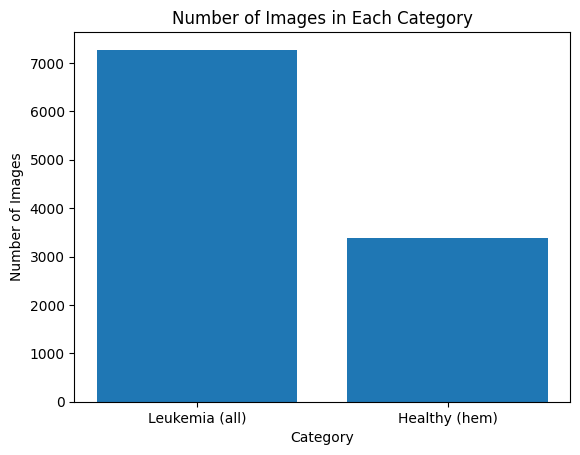

In [4]:
dataset_path = "/content/Blood_Cancer_Datasets"
folders = ['fold_0','fold_1','fold_2']

all_count = 0
hem_count = 0

for f in folders:
  all_dir = os.path.join(dataset_path, f, f, 'all')
  hem_dir = os.path.join(dataset_path, f,f,'hem')

  if os.path.exists(all_dir):
    all_count = all_count + len(os.listdir(all_dir))
  if os.path.exists(hem_dir):
    hem_count = hem_count + len(os.listdir(hem_dir))

print("Leukemia(all) :",all_count)
print("Healthy (hem): ", hem_count)

categories = ['Leukemia (all)', 'Healthy (hem)']
counts = [all_count, hem_count]

plt.figure()
plt.bar(categories, counts)
plt.title("Number of Images in Each Category")
plt.xlabel("Category")
plt.ylabel("Number of Images")
plt.show()

# **Samples Image ouput from the dataset to view how the images look before preprocessing.**

Found the Main Directory, now digging deep into the hierarichal structure to search for images


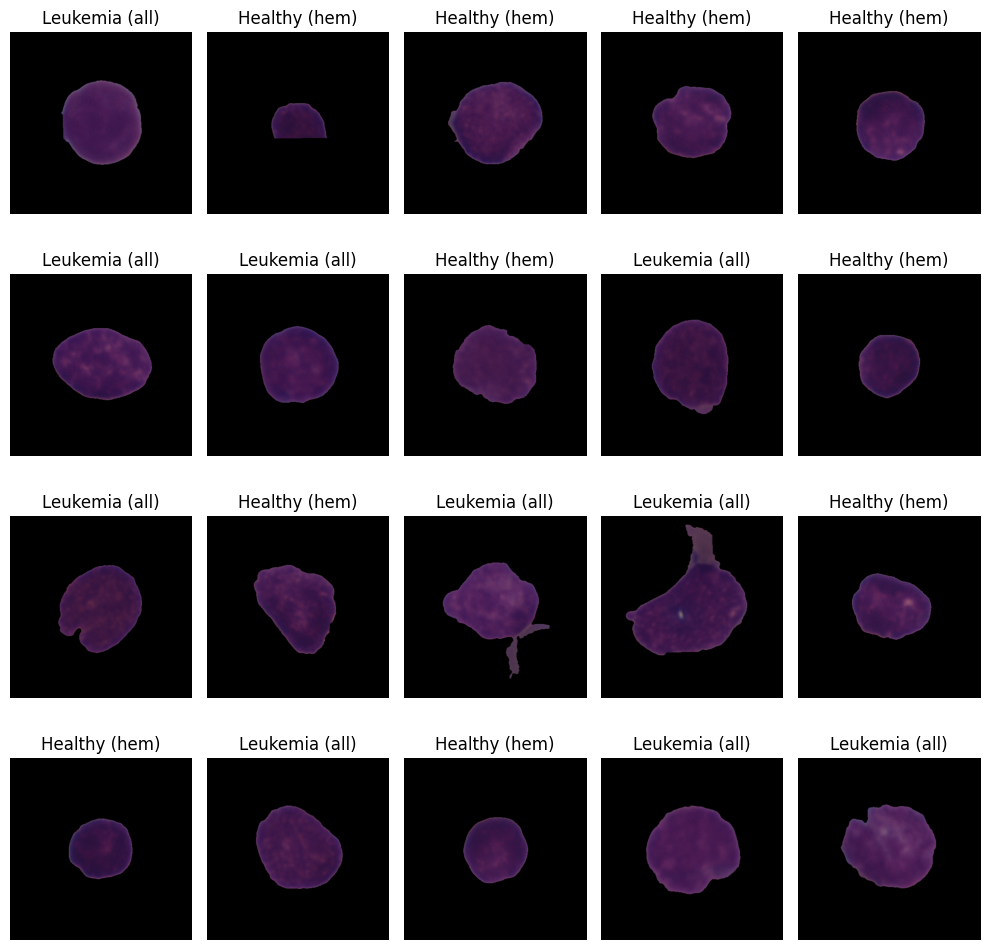

In [5]:
dataset_path = "/content/Blood_Cancer_Datasets"
folders = ['fold_0','fold_1','fold_2']
all_leukemia = []
healthy = []
if os.path.exists(dataset_path):
  print("Found the Main Directory, now digging deep into the hierarichal structure to search for images")
  for f in folders:
    all_leukemia_dir = os.path.join(dataset_path, f,f,'all')
    healthy_dir = os.path.join(dataset_path,f, f,'hem')

    if os.path.exists(all_leukemia_dir):
      all_leukemia.extend([os.path.join(all_leukemia_dir,i) for i in os.listdir(all_leukemia_dir)])
      if os.path.exists(healthy_dir):
        healthy.extend([os.path.join(healthy_dir,i) for i in os.listdir(healthy_dir)])

else:
  print("There is an error looking for the base path")

sample_class = random.sample(all_leukemia,10)
sample_class.extend(random.sample(healthy, 10))
random.shuffle(sample_class)

plt.figure(figsize=(10,10))
for i, path in enumerate(sample_class):
  img = cv2.imread(path)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  label = "Leukemia (all)" if "all" in path else "Healthy (hem)"
  plt.subplot(4, 5, i + 1)
  plt.imshow(img)
  plt.title(label)
  plt.axis('off')
plt.tight_layout()
plt.show()

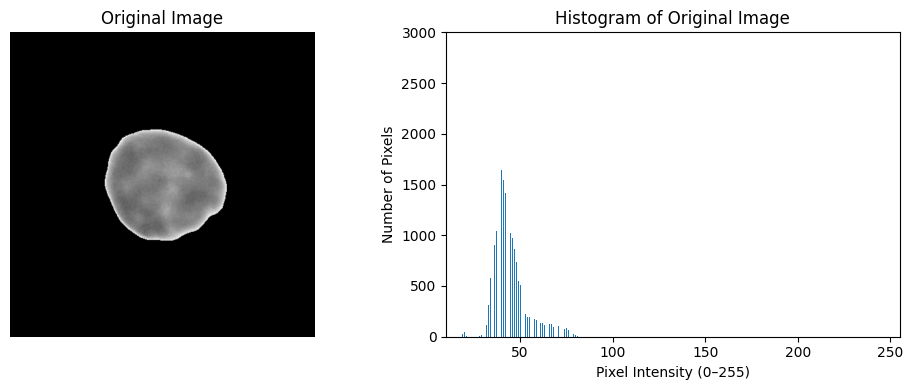

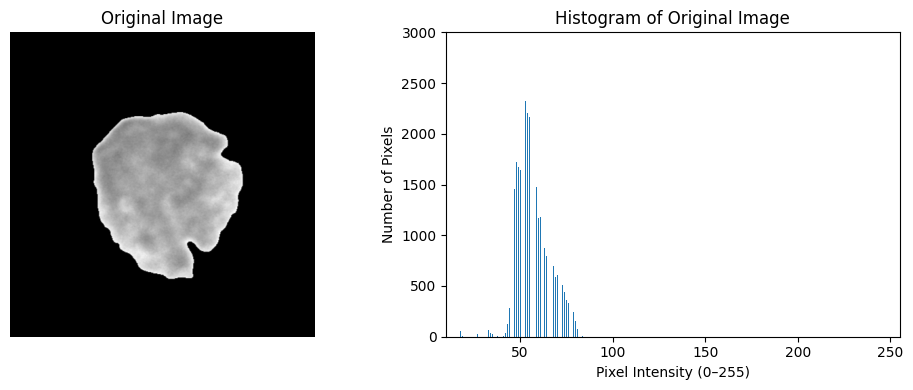

In [6]:
paths = [
"/content/Blood_Cancer_Datasets/fold_0/fold_0/hem/UID_H11_10_1_hem.bmp",
"/content/Blood_Cancer_Datasets/fold_0/fold_0/all/UID_11_10_1_all.bmp"
]

for p in paths:

    img = cv2.imread(p)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(gray, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.hist(gray.ravel(), bins=256)
    plt.title("Histogram of Original Image")
    plt.xlabel("Pixel Intensity (0–255)")
    plt.ylabel("Number of Pixels")
    plt.xlim([10, 255])
    plt.ylim([0, 3000])
    plt.tight_layout()
    plt.show()

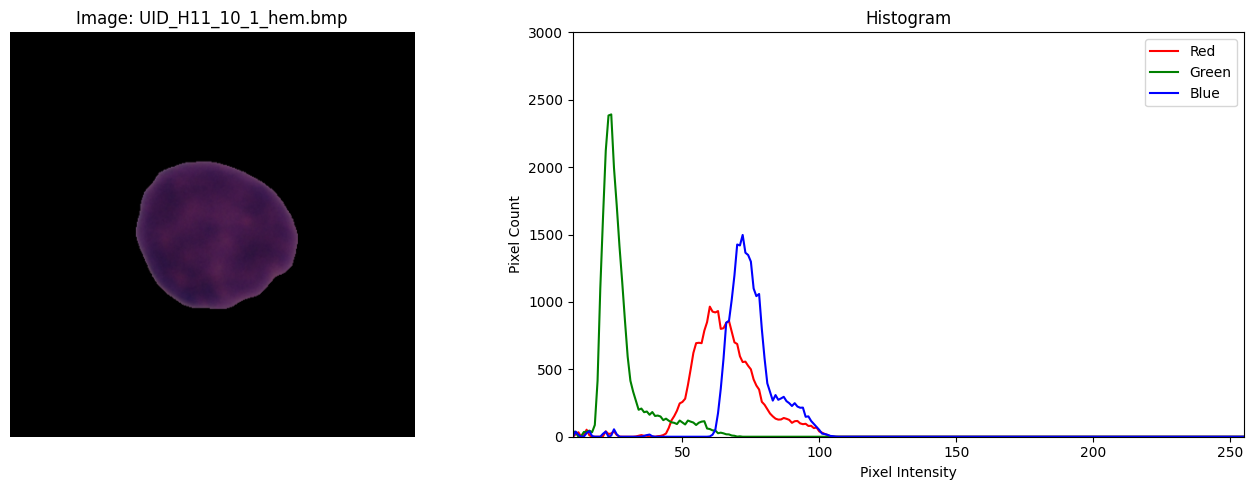

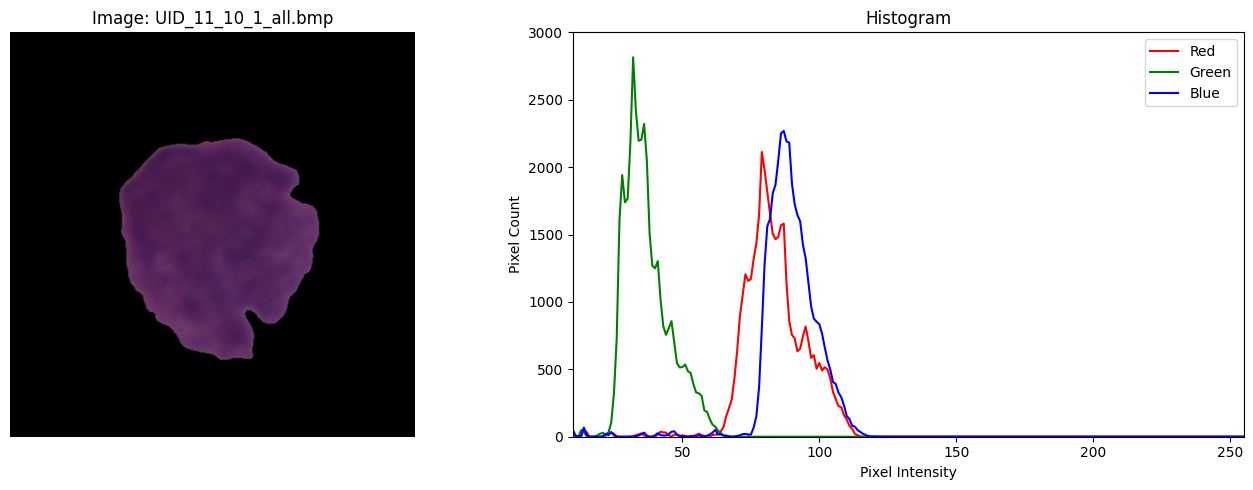

In [7]:
paths = [
"/content/Blood_Cancer_Datasets/fold_0/fold_0/hem/UID_H11_10_1_hem.bmp",
"/content/Blood_Cancer_Datasets/fold_0/fold_0/all/UID_11_10_1_all.bmp"
]

for p in paths:
    img = cv2.imread(p)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    r = img[:,:,0]
    g = img[:,:,1]
    b = img[:,:,2]

    hist_r = cv2.calcHist([r], [0], None, [256], [0,256])
    hist_g = cv2.calcHist([g], [0], None, [256], [0,256])
    hist_b = cv2.calcHist([b], [0], None, [256], [0,256])

    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title(f"Image: {p.split('/')[-1]}")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.plot(hist_r, color="red", label="Red")
    plt.plot(hist_g, color="green", label="Green")
    plt.plot(hist_b, color="blue", label="Blue")

    plt.legend()
    plt.title("Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Pixel Count")
    plt.xlim([10, 255])
    plt.ylim([0, 3000])
    plt.tight_layout()
    plt.show()

# ** This function calculates the global color distribution (mean and standard deviation) of the dataset to establish a baseline for consistent stain normalization across all the microscopic images.**





In [8]:
def compute_dataset_stain_stats(all_paths, n_samples = 300):
    sample = random.sample(list(all_paths), min(n_samples, len(all_paths)))
    means, std = [], []
    skipped = 0

    for idx, path in enumerate(sample):
        try:
            img = cv2.imread(path)
            if img is None:
                print(f"[SKIP] Failed to load: {path}")
                skipped += 1
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
            gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
            mask = gray > 15
            if mask.sum() < 100:
                skipped += 1
                continue
            pixels = img[mask]
            means.append(pixels.mean(axis=0))
            std.append(pixels.std(axis=0))
        except Exception as e:
            print(f"[ERROR] Exception in {path}: {str(e)}")
            skipped += 1
            continue

    if len(means) == 0:
        raise ValueError(f"[CRITICAL] No valid images for stain normalization!")

    target_mean = np.mean(means, axis=0)
    target_std  = np.mean(std, axis=0)
    print(f"Mean: {target_mean}")
    print(f"Std: {target_std}")
    print(f"Skipped: {skipped} images\n")
    return target_mean, target_std

all_paths = all_leukemia + healthy
target_mean, target_std = compute_dataset_stain_stats(all_paths)

Mean: [68.834915 29.541397 79.50314 ]
Std: [10.972305  8.662467  9.064144]
Skipped: 0 images



# **This proprocessing piepline implements a multi-stage enhancement stratergy - including stain normalization, CLAHE contrast adjustment and bilateral filtering, to standardize the visual chracterstics of blood smear images and highlight critical nuclear features for the deep learning model **

In [9]:
from scipy import ndimage
def normalize_stain(img, target_mean, target_std):
  img_float = img.astype(np.float32)
  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  cell_mask = gray>15
  for i in range(3):
    channel = img_float[:,:,i]
    cell_pixels = channel[cell_mask]
    if len(cell_pixels)<100:
      continue
    src_mean = np.mean(cell_pixels)
    src_std = np.std(cell_pixels) + 1e-6
    normalized = (channel - src_mean) / src_std
    img_float[:,:,i] = normalized * target_std[i] + target_mean[i]
  result = np.clip(img_float, 0, 255).astype(np.uint8)
  result[~cell_mask] = [0,0,0]
  return result


def preprocess_img(img_path,target_mean, target_std, size=(224,224)):
    img = cv2.imread(img_path)
    if img is None:
      print(f"Error loading image: {img_path}")
      return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = normalize_stain(img, target_mean, target_std)
    img =cv2.resize(img, size, interpolation = cv2.INTER_LANCZOS4)

    lab     = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe   = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l       = clahe.apply(l)
    img     = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2RGB)

    blurred = cv2.GaussianBlur(img, (3, 3), sigmaX=1.0)
    img     = cv2.addWeighted(img, 1.4, blurred, -0.4, 0)
    img     = np.clip(img, 0, 255).astype(np.uint8)
    img = cv2.bilateralFilter(img, d=5, sigmaColor=30, sigmaSpace=30)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    final_mask = gray > 15
    img[~final_mask] = [0,0,0]

    return img

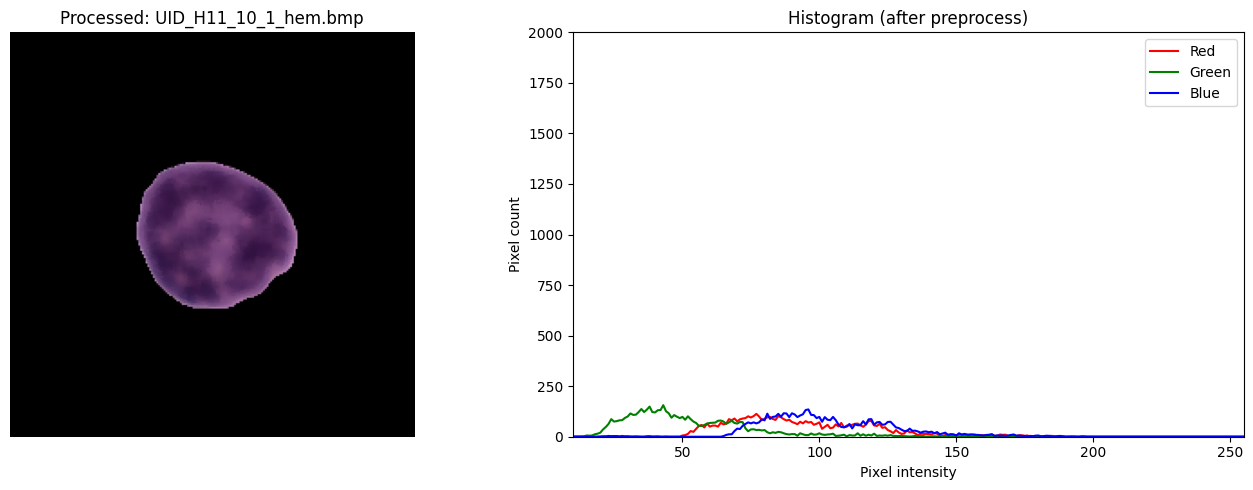

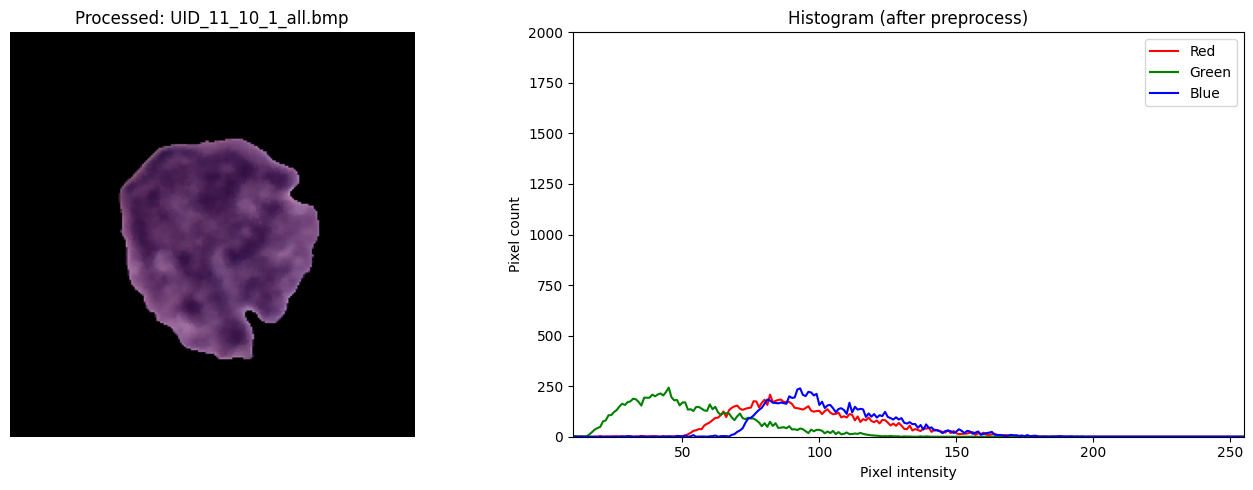

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

target_mean = np.array([70.26929, 30.359186, 80.483795], dtype=np.float32)
target_std = np.array([11.065046, 8.770111, 9.151098], dtype=np.float32)

paths = [
    "/content/Blood_Cancer_Datasets/fold_0/fold_0/hem/UID_H11_10_1_hem.bmp",
    "/content/Blood_Cancer_Datasets/fold_0/fold_0/all/UID_11_10_1_all.bmp",
]

for p in paths:
    img = preprocess_img(p, target_mean, target_std, size=(224, 224))
    if img is None:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].imshow(img)
    axes[0].set_title(f"Processed: {p.split('/')[-1]}")
    axes[0].axis("off")

    colors = ("red", "green", "blue")
    for i, c in enumerate(colors):
        h = cv2.calcHist([img[:, :, i]], [0], None, [256], [0, 256])
        axes[1].plot(h, color=c, label=c.capitalize())

    axes[1].set_title("Histogram (after preprocess)")
    axes[1].set_xlabel("Pixel intensity")
    axes[1].set_ylabel("Pixel count")
    axes[1].set_xlim(10, 255)
    axes[1].set_ylim(0, 2000)
    axes[1].legend()
    fig.tight_layout()
    plt.show()

# **These are the preprocessed images with their specific classification.**

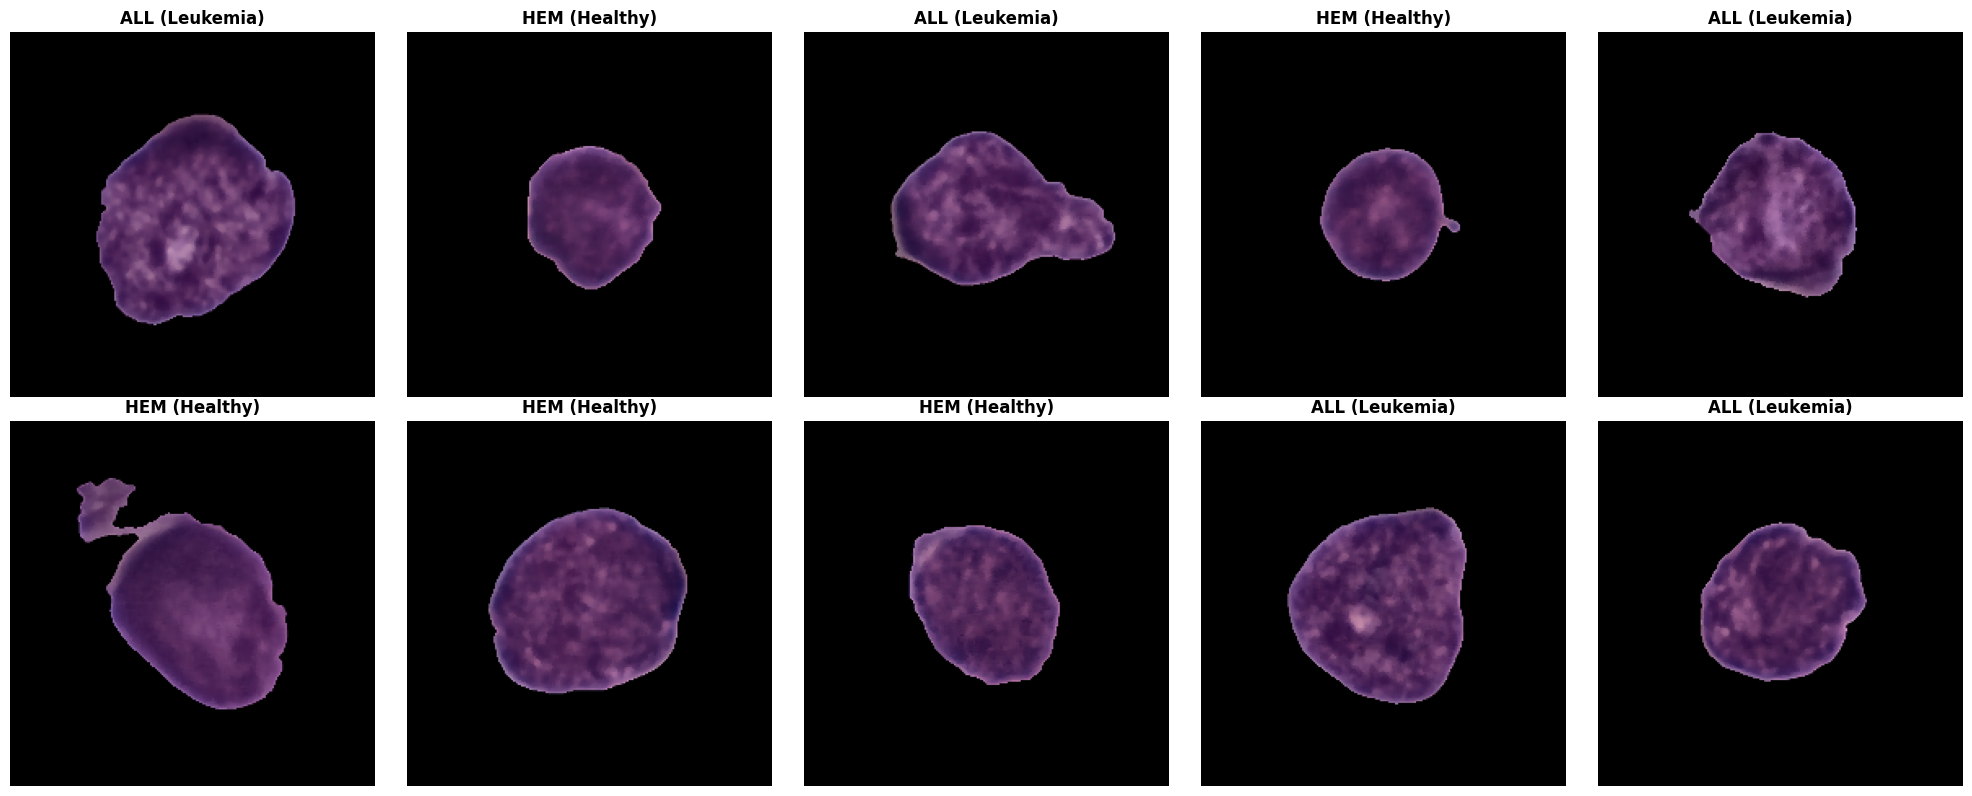

In [13]:
leukemia_samples = random.sample(all_leukemia, 5)
healthy_samples = random.sample(healthy, 5)
mixed_samples = leukemia_samples + healthy_samples
random.shuffle(mixed_samples)


rows = 2
cols = 5

plt.figure(figsize=(20, 8))

for i, raw_path in enumerate(mixed_samples):
    original_img = cv2.imread(raw_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)


    preprocessed_img = preprocess_img(raw_path, target_mean, target_std)


    label = "ALL (Leukemia)" if "all" in raw_path else "HEM (Healthy)"


    plt.subplot(rows, cols, i + 1)
    plt.imshow(preprocessed_img)
    plt.title(f"{label}", fontsize=12, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.savefig("horizontal_preprocessing_grid.png", dpi=300, bbox_inches='tight')
plt.show()

# **A step by step visulization to make the preprocessing implementation more clear. **

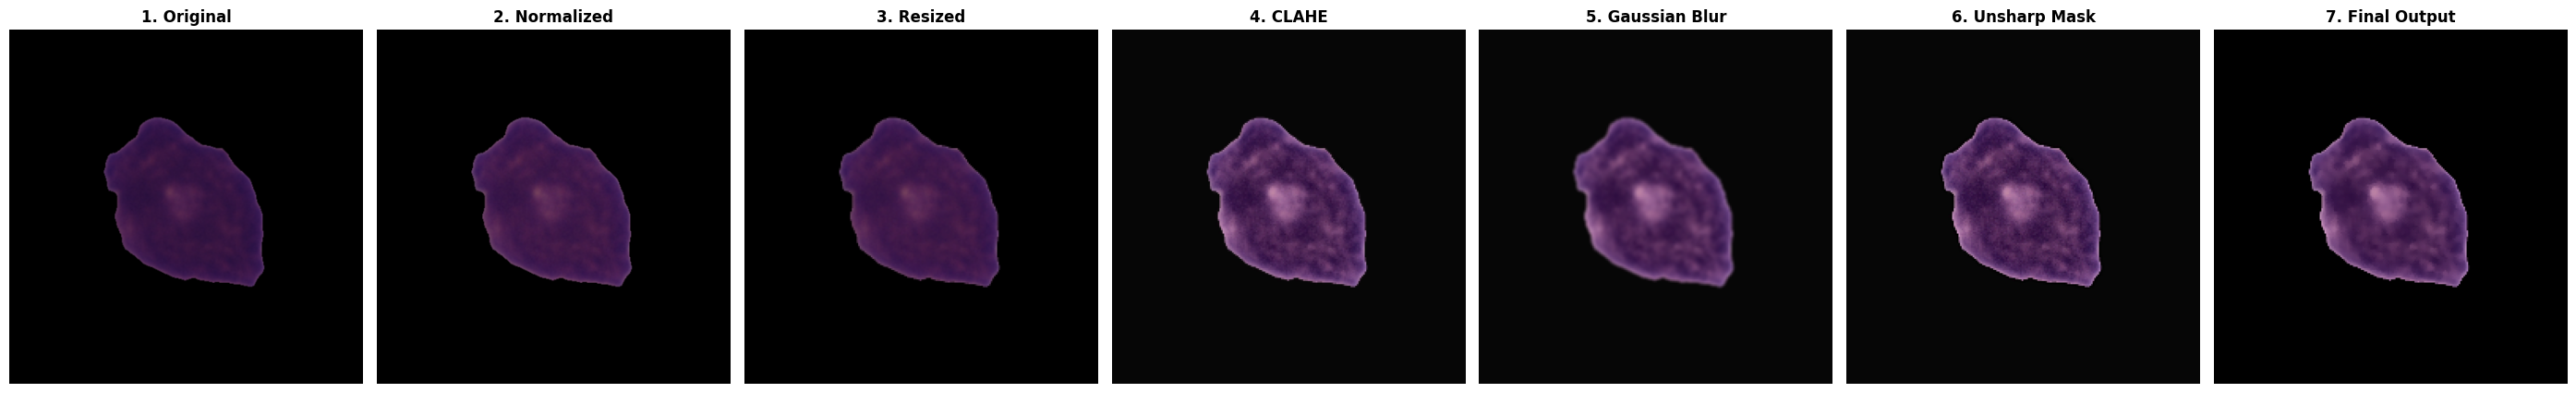

In [11]:

sample_path = all_leukemia[0]
original = cv2.imread(sample_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)


stain_norm = normalize_stain(original, target_mean, target_std)


resized = cv2.resize(stain_norm, (224, 224), interpolation=cv2.INTER_LANCZOS4)

lab = cv2.cvtColor(resized, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
l = clahe.apply(l)
enhanced = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2RGB)


blurred = cv2.GaussianBlur(enhanced, (3, 3), sigmaX=1.0)


sharpened = cv2.addWeighted(enhanced, 1.4, blurred, -0.4, 0)
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)


final_filtered = cv2.bilateralFilter(sharpened, d=5, sigmaColor=30, sigmaSpace=30)
gray = cv2.cvtColor(final_filtered, cv2.COLOR_RGB2GRAY)
final_filtered[gray <= 15] = [0, 0, 0]


titles = [
    "1. Original",
    "2. Normalized",
    "3. Resized",
    "4. CLAHE",
    "5. Gaussian Blur",
    "6. Unsharp Mask",
    "7. Final Output"
]
images = [original, stain_norm, resized, enhanced, blurred, sharpened, final_filtered]


plt.figure(figsize=(28, 5))

for i in range(len(images)):
    plt.subplot(1, 7, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i], fontsize=12, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

# **For VGG16, this ImageBatchLoader class acts as a custom data pipeline that efficiently feeds the model by handling real-time image loading, preprocessing, on-the-fly data augmentation, and normalization in organized batches. **

In [14]:
class ImageBatchLoader(Sequence):

    def __init__(self, img_paths, labels,target_mean, target_std, augment=False, batch_size=32, shuffle=True):
        self.img_paths  = img_paths
        self.labels     = labels
        self.target_mean = target_mean
        self.target_std = target_std
        self.batch_size = batch_size
        self.shuffle    = shuffle
        self.augment    = augment

        self.order = np.arange(len(img_paths))
        if self.shuffle:
            np.random.shuffle(self.order)

    def __len__(self):
        total_batches = int(np.ceil(len(self.img_paths) / self.batch_size))
        return total_batches

    def __getitem__(self, batch_number):
        start       = batch_number * self.batch_size
        end         = start + self.batch_size
        batch_order = self.order[start:end]

        batch_paths  = [self.img_paths[i] for i in batch_order]
        batch_labels = [self.labels[i]    for i in batch_order]

        images_loaded = []

        for path in batch_paths:
            img = preprocess_img(path, self.target_mean, self.target_std)

            if img is None:
                img = np.zeros((224, 224, 3), dtype=np.uint8)

            if self.augment:
                if random.random() > 0.5:
                    img = cv2.flip(img, 1)
                if random.random() > 0.5:
                    img = cv2.flip(img, 0)
                angle    = random.uniform(-15, 15)
                rotation = cv2.getRotationMatrix2D((112, 112), angle, 1.0)
                img      = cv2.warpAffine(img, rotation, (224, 224), borderMode = cv2.BORDER_REPLICATE)







            img  = img.astype(np.float32) / 255.0
            mean = np.array([0.485, 0.456, 0.406])
            sd   = np.array([0.229, 0.224, 0.225])
            img  = (img - mean) / sd


            images_loaded.append(img)

        return np.array(images_loaded), np.array(batch_labels, dtype=np.float32)


    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.order)

# **This loader is for efficientnetB0, it provides raw float 32 pixels data without external normalization, as the EfficientNetB0 architecture handles scaling through it owns internal rescaling layers. **

In [15]:
class ImageBatchLoader_EfficientNet(Sequence):

    def __init__(self, img_paths, labels,target_mean, target_std, augment=False, batch_size=32, shuffle=True):
        self.img_paths  = img_paths
        self.labels     = labels
        self.target_mean = target_mean
        self.target_std = target_std
        self.batch_size = batch_size
        self.shuffle    = shuffle
        self.augment    = augment

        self.order = np.arange(len(img_paths))
        if self.shuffle:
            np.random.shuffle(self.order)

    def __len__(self):
        total_batches = int(np.ceil(len(self.img_paths) / self.batch_size))
        return total_batches

    def __getitem__(self, batch_number):
        start       = batch_number * self.batch_size
        end         = start + self.batch_size
        batch_order = self.order[start:end]

        batch_paths  = [self.img_paths[i] for i in batch_order]
        batch_labels = [self.labels[i]    for i in batch_order]

        images_loaded = []

        for path in batch_paths:
            img = preprocess_img(path, self.target_mean, self.target_std)

            if img is None:
                img = np.zeros((224, 224, 3), dtype=np.uint8)

            if self.augment:
                if random.random() > 0.5:
                    img = cv2.flip(img, 1)
                if random.random() > 0.5:
                    img = cv2.flip(img, 0)
                angle    = random.uniform(-15, 15)
                rotation = cv2.getRotationMatrix2D((112, 112), angle, 1.0)
                img      = cv2.warpAffine(img, rotation, (224, 224), borderMode = cv2.BORDER_REPLICATE)







            img  = img.astype(np.float32)


            images_loaded.append(img)

        return np.array(images_loaded), np.array(batch_labels, dtype=np.float32)


    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.order)

# **This loader for InceptionV3, resizes images to 299 X 299 and employs inception_preprocess to shift pixels intensities to the required [-1,1] range for optimal feature extraction. **

In [16]:
class ImageBatchLoader_InceptionV3(Sequence):
    def __init__(
        self,
        img_paths,
        labels,
        target_mean,
        target_std,
        augment=False,
        batch_size=16,
        shuffle=True,
        drop_failed=False
    ):
        super().__init__()
        self.img_paths = np.array(img_paths)
        self.labels = np.array(labels)
        self.target_mean = target_mean
        self.target_std = target_std
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.drop_failed = drop_failed
        self.order = np.arange(len(self.img_paths))
        if self.shuffle:
            np.random.shuffle(self.order)

    def __len__(self):
        return int(np.ceil(len(self.img_paths) / self.batch_size))

    def __getitem__(self, batch_number):
        start = batch_number * self.batch_size
        end = start + self.batch_size
        batch_order = self.order[start:end]

        batch_paths = [self.img_paths[i] for i in batch_order]
        batch_labels = [self.labels[i] for i in batch_order]

        images_loaded = []
        valid_labels = []

        for idx, path in enumerate(batch_paths):
            try:
                img = preprocess_img(path, self.target_mean, self.target_std, size=(299, 299))
                if img is None:
                    raise ValueError("preprocess_img returned None")

                if self.augment:
                    if random.random() > 0.5:
                        img = cv2.flip(img, 1)
                    if random.random() > 0.5:
                        img = cv2.flip(img, 0)

                    angle = random.uniform(-15, 15)
                    rot = cv2.getRotationMatrix2D((149.5, 149.5), angle, 1.0)
                    img = cv2.warpAffine(
                        img, rot, (299, 299),
                        flags=cv2.INTER_LINEAR,
                        borderMode=cv2.BORDER_REPLICATE
                    )

                img = img.astype(np.float32)


                img = np.clip(img, 0.0, 255.0)
                img = inception_preprocess(img)

                images_loaded.append(img)
                valid_labels.append(batch_labels[idx])

            except Exception as e:
                if self.drop_failed:

                    if len(images_loaded) < 3:
                        print(f"[BATCH WARN] Skipped: {path} | {e}")
                    continue
                else:

                    fallback = np.zeros((299, 299, 3), dtype=np.float32)
                    fallback = inception_preprocess(fallback)
                    images_loaded.append(fallback)
                    valid_labels.append(batch_labels[idx])

        if len(images_loaded) == 0:
            raise RuntimeError(f"[CRITICAL] Batch {batch_number}: no valid images")

        return np.array(images_loaded, dtype=np.float32), np.array(valid_labels, dtype=np.float32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.order)

# **This loader for ResNet50 utilizes the built-in resnet_preprocess function to ensure input data aligns with the specific mathematical scaling and BGR color-channel requirements of the ResNet architecture.**

In [17]:


class ImageBatchLoaderResNet(Sequence):
    def __init__(self, img_paths, labels, target_mean, target_std, augment=False, batch_size=32, shuffle=True):
        self.img_paths = np.asarray(img_paths)
        self.labels = np.asarray(labels, dtype=np.float32)
        self.target_mean = target_mean
        self.target_std = target_std
        self.augment = augment
        self.batch_size = int(batch_size)
        self.shuffle = shuffle
        self.order = np.arange(len(self.img_paths))
        if self.shuffle:
            np.random.shuffle(self.order)

    def __len__(self):
        return int(np.ceil(len(self.img_paths) / self.batch_size))

    def __getitem__(self, idx):
        start = idx * self.batch_size
        end = start + self.batch_size
        batch_idx = self.order[start:end]
        batch_paths = self.img_paths[batch_idx]
        batch_labels = self.labels[batch_idx]
        images = []

        for p in batch_paths:
            img = preprocess_img(p, self.target_mean, self.target_std)
            if img is None:
                img = np.zeros((224, 224, 3), dtype=np.uint8)

            if self.augment:
                if random.random() > 0.5:
                    img = cv2.flip(img, 1)
                if random.random() > 0.5:
                    img = cv2.flip(img, 0)
                angle = random.uniform(-15, 15)
                M = cv2.getRotationMatrix2D((112, 112), angle, 1.0)
                img = cv2.warpAffine(img, M, (224, 224), borderMode=cv2.BORDER_REPLICATE)

            x = img.astype(np.float32)
            x = resnet_preprocess(np.expand_dims(x, 0))[0]
            images.append(x)

        return np.asarray(images, dtype=np.float32), np.asarray(batch_labels, dtype=np.float32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.order)

# **This code calculates and assigns inverse-frequency class weights to balance the loss function, ensuring that model gives equal importance to both the classes (ALL and HEM) despite the difference in their sample sizes. **

In [19]:
total= all_count + hem_count
weight_all = total/ (2* all_count)
weight_hem = total/ (2* hem_count)
class_weights = {1:weight_all, 0:weight_hem}
print(f"Weight for all: {weight_all:.2f}")
print(f"Weight for hem: {weight_hem: .2f}")

Weight for all: 0.73
Weight for hem:  1.57


# **In this code the 3-fold cross-validation configuration and the necessary data structures to store the performance metrics, training histories, and evaluation reports for each experimental iteration. **

In [20]:


fold_splits = [
    {
        'train': ['fold_1', 'fold_2'], 'val':'fold_0'},
    {
        'train': ['fold_0', 'fold_2'], 'val':'fold_1'},
    {
        'train': ['fold_0', 'fold_1'], 'val':'fold_2'}
]
fold_accuracies = []
fold_reports = []
fold_confusion_matrices = []
fold_histories= []

# **For VGG16**

In [21]:
def build_vgg16():
  base = VGG16(weights='imagenet', include_top = False, input_shape = (224,224,3))
  base.trainable = False
  model = Sequential(
      [
          base,
          GlobalAveragePooling2D(),
          BatchNormalization(),
          Dense(512, activation='relu'),
          Dropout(0.5),
          Dense(256, activation='relu'),
          Dropout(0.3),
          Dense(1, activation='sigmoid')
      ]


  )



  model.compile(optimizer = Adam(learning_rate = 1e-4),
                loss = "binary_crossentropy",
                metrics = ["accuracy"])
  return model



# **For EfficientNetB0**

In [22]:
def build_efficientnetb0():
  base = EfficientNetB0(
      weights = 'imagenet',
      include_top = False,
      input_shape = (224,224,3)
  )
  base.trainable = False
  model = Sequential([
      base,
      GlobalAveragePooling2D(),
      BatchNormalization(),
      Dense(512, activation = 'relu'),
      Dropout(0.5),
      Dense(256, activation='relu'),
      Dropout(0.3),
      Dense(1, activation='sigmoid')
  ])
  model.compile(
      optimizer = Adam(learning_rate = 1e-4),
      loss = 'binary_crossentropy',
      metrics = ['accuracy']
  )
  return model

# **For InceptionV3**

In [23]:
def build_inceptionv3_feature_extractor():
    base = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(299, 299, 3)
    )
    base.trainable = False

    model = Sequential([
        base,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.02),
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

# **I used ResNet50 for a two-stage training strategy to test if adapting the pre-trained high-level filters would yield higher sensitivity for leukemia detection compared to the static feature extraction**

In [24]:


def build_resnet50():
    base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base.trainable = False  # stage 1 frozen

    model = Sequential([
        base,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dense(512, activation="relu"),
        Dropout(0.5),
        Dense(256, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.01),
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model


def unfreeze_resnet_top(model, n_trainable_layers=30):
    base = model.layers[0]
    base.trainable = True

    for layer in base.layers[:-n_trainable_layers]:
        layer.trainable = False

    for layer in base.layers[-n_trainable_layers:]:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

    model.compile(
        optimizer=Adam(learning_rate=1e-5),  # lower LR for fine-tuning
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.01),
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model

# **This loop implements a robust 3-fold cross-validation process using a frozen VGG16 backbone and manual ImageNet-based pixel normalization to establish a baseline for leukemia classification.**

In [27]:
import json


CKPT_DIR = "/content/drive/MyDrive/Leukemia_Newww_Research_Results"
os.makedirs(CKPT_DIR, exist_ok=True)
RESULTS_PATH = os.path.join(CKPT_DIR, "fold_results.json")

print(f"All models and graphs will be saved to: {CKPT_DIR}")


def save_learning_curves(history, fold, save_dir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history['accuracy'],     label='Train Accuracy', color='blue')
    axes[0].plot(history['val_accuracy'], label='Val Accuracy',   color='orange')
    axes[0].set_title(f'Fold {fold} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[1].plot(history['loss'],     label='Train Loss', color='blue')
    axes[1].plot(history['val_loss'], label='Val Loss',   color='orange')
    axes[1].set_title(f'Fold {fold} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    plt.tight_layout()
    path = os.path.join(save_dir, f'vgg16_fold_{fold}_curves.png')
    plt.savefig(path, dpi=150)
    plt.close()

def save_confusion_matrix(cm, fold, save_dir):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Healthy (hem)', 'Leukemia (all)'],
                yticklabels=['Healthy (hem)', 'Leukemia (all)'])
    plt.title(f'Confusion Matrix — Fold {fold}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    path = os.path.join(save_dir, f'confusion_matrix_fold_{fold}.png')
    plt.savefig(path, dpi=150)
    plt.close()

def save_final_bar_chart(accuracies, save_dir):
    plt.figure(figsize=(8, 5))
    bars = plt.bar([f"Fold {i+1}" for i in range(len(accuracies))], accuracies,
                   color=['#4CAF50' if a == max(accuracies) else '#2196F3' for a in accuracies])
    plt.axhline(y=np.mean(accuracies), color='red', linestyle='--', label=f"Mean: {np.mean(accuracies):.4f}")
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{acc*100:.2f}%", ha='center', fontsize=11)
    plt.title("K-Fold Cross Validation — Accuracy per Fold")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.1)
    plt.legend()
    plt.tight_layout()
    path = os.path.join(save_dir, 'fold_accuracies_chart.png')
    plt.savefig(path, dpi=150)
    plt.close()


batch_size = 32
epochs = 40
start_fold = 0


if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, 'r') as f:
        saved = json.load(f)
    fold_accuracies = saved['accuracies']
    fold_histories  = saved['histories']
    fold_confusion_matrices = [np.array(cm) for cm in saved['cms']]
    fold_reports    = saved['reports']
    start_fold      = saved['completed_folds']
    print(f"Resuming from fold {start_fold + 1}")

for fold, split in enumerate(fold_splits):
    if fold < start_fold:
        continue

    print(f"\n{'='*50}\nSTARTING FOLD {fold+1} / 3\n{'='*50}")


    train_paths, train_labels = [], []
    for f in split['train']:
        all_dir = os.path.join(dataset_path, f, f, 'all')
        hem_dir = os.path.join(dataset_path, f, f, 'hem')
        if os.path.exists(all_dir):
            for img in os.listdir(all_dir):
                train_paths.append(os.path.join(all_dir, img))
                train_labels.append(1)
        if os.path.exists(hem_dir):
            for img in os.listdir(hem_dir):
                train_paths.append(os.path.join(hem_dir, img))
                train_labels.append(0)


    val_paths, val_labels = [], []
    val_folders = [split['val']]
    for f in val_folders:
        all_dir = os.path.join(dataset_path, f, f, 'all')
        hem_dir = os.path.join(dataset_path, f, f, 'hem')
        if os.path.exists(all_dir):
            for img in os.listdir(all_dir):
                val_paths.append(os.path.join(all_dir, img))
                val_labels.append(1)
        if os.path.exists(hem_dir):
            for img in os.listdir(hem_dir):
                val_paths.append(os.path.join(hem_dir, img))
                val_labels.append(0)

    train_paths, train_labels = np.array(train_paths), np.array(train_labels)
    val_paths, val_labels = np.array(val_paths), np.array(val_labels)

    print(f"Training on {len(train_paths)} images | Validating on {len(val_paths)} images")


    train_gen = ImageBatchLoader(train_paths, train_labels,target_mean, target_std, augment=True,  batch_size=batch_size, shuffle=True)
    val_gen   = ImageBatchLoader(val_paths,   val_labels,target_mean, target_std,   augment=False, batch_size=batch_size, shuffle=False)


    tf.keras.backend.clear_session()
    model = build_vgg16()

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr = 1e-8),
        ModelCheckpoint(filepath=os.path.join(CKPT_DIR, f'best_weights_fold_{fold+1}.keras'), monitor='val_loss', save_best_only=True, verbose=0)
    ]

    history = model.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=callbacks, class_weight=class_weights, verbose=1)

    model_path = os.path.join(CKPT_DIR, f'vgg16_fold_{fold+1}.h5')
    model.save(model_path)


    val_gen_eval = ImageBatchLoader(val_paths, val_labels,target_mean, target_std, augment=False, batch_size=batch_size, shuffle=False)
    y_prob = model.predict(val_gen_eval, verbose=0)
    y_pred = (y_prob > 0.5).astype(int).flatten()

    acc    = accuracy_score(val_labels, y_pred)
    report = classification_report(val_labels, y_pred, target_names=['Healthy (hem)', 'Leukemia (all)'])
    cm     = confusion_matrix(val_labels, y_pred)

    fold_accuracies.append(acc)
    fold_reports.append(report)
    fold_confusion_matrices.append(cm)
    fold_histories.append(history.history)

    print(f"\n---> FOLD {fold+1} FINISHED! Accuracy: {acc:.4f}\n")


    save_learning_curves(history.history, fold+1, CKPT_DIR)
    save_confusion_matrix(cm, fold+1, CKPT_DIR)

    with open(RESULTS_PATH, 'w') as file:
        json.dump({
            'accuracies':      fold_accuracies,
            'histories':       fold_histories,
            'cms':             [c.tolist() for c in fold_confusion_matrices],
            'reports':         fold_reports,
            'completed_folds': fold + 1
        }, file)

avg_acc, std_acc = np.mean(fold_accuracies), np.std(fold_accuracies)
save_final_bar_chart(fold_accuracies, CKPT_DIR)

report_path = os.path.join(CKPT_DIR, "vgg16_research_results.txt")
with open(report_path, "w") as file:
    file.write("=" * 60 + "\n   VGG16 K-FOLD CROSS VALIDATION — RESEARCH RESULTS\n" + "=" * 60 + "\n\n")
    for i in range(len(fold_accuracies)):
        file.write(f"--- FOLD {i+1} ---\nAccuracy : {fold_accuracies[i]:.4f}\n\nClassification Report:\n{fold_reports[i]}\nConfusion Matrix:\n{fold_confusion_matrices[i]}\n\n" + "-" * 40 + "\n\n")
    file.write("=" * 60 + "\nFINAL AGGREGATE METRICS\n" + "=" * 60 + "\n")
    file.write(f"Average Accuracy  : {avg_acc:.4f}\nStandard Deviation: {std_acc:.4f}\n")
    file.write(f"Paper format -> {avg_acc*100:.2f}% ± {std_acc*100:.2f}%\n")



All models and graphs will be saved to: /content/drive/MyDrive/Leukemia_Newww_Research_Results
Resuming from fold 4


# **This process leverages the EfficientNetB0 architecture's internal rescaling layers to streamline the data pipeline, feeding raw pixel data directly to the model to optimize computational efficiency.**

In [26]:
import json


CKPT_DIR = "/content/drive/MyDrive/Leukemia_Research_Results_EfficientNet"
os.makedirs(CKPT_DIR, exist_ok=True)
RESULTS_PATH = os.path.join(CKPT_DIR, "fold_results.json")

print(f"All models and graphs will be saved to: {CKPT_DIR}")


def save_learning_curves(history, fold, save_dir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history['accuracy'],     label='Train Accuracy', color='blue')
    axes[0].plot(history['val_accuracy'], label='Val Accuracy',   color='orange')
    axes[0].set_title(f'Fold {fold} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[1].plot(history['loss'],     label='Train Loss', color='blue')
    axes[1].plot(history['val_loss'], label='Val Loss',   color='orange')
    axes[1].set_title(f'Fold {fold} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    plt.tight_layout()
    path = os.path.join(save_dir, f'efficentnetb0_fold_{fold}_curves.png')
    plt.savefig(path, dpi=150)
    plt.close()

def save_confusion_matrix(cm, fold, save_dir):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Healthy (hem)', 'Leukemia (all)'],
                yticklabels=['Healthy (hem)', 'Leukemia (all)'])
    plt.title(f'Confusion Matrix — Fold {fold}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    path = os.path.join(save_dir, f'confusion_matrix_fold_{fold}.png')
    plt.savefig(path, dpi=150)
    plt.close()

def save_final_bar_chart(accuracies, save_dir):
    plt.figure(figsize=(8, 5))
    bars = plt.bar([f"Fold {i+1}" for i in range(len(accuracies))], accuracies,
                   color=['#4CAF50' if a == max(accuracies) else '#2196F3' for a in accuracies])
    plt.axhline(y=np.mean(accuracies), color='red', linestyle='--', label=f"Mean: {np.mean(accuracies):.4f}")
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{acc*100:.2f}%", ha='center', fontsize=11)
    plt.title("K-Fold Cross Validation — Accuracy per Fold")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.1)
    plt.legend()
    plt.tight_layout()
    path = os.path.join(save_dir, 'fold_accuracies_chart.png')
    plt.savefig(path, dpi=150)
    plt.close()


batch_size = 32
epochs = 30
start_fold = 0


if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, 'r') as f:
        saved = json.load(f)
    fold_accuracies = saved['accuracies']
    fold_histories  = saved['histories']
    fold_confusion_matrices = [np.array(cm) for cm in saved['cms']]
    fold_reports    = saved['reports']
    start_fold      = saved['completed_folds']
    print(f"Resuming from fold {start_fold + 1}")

for fold, split in enumerate(fold_splits):
    if fold < start_fold:
        continue

    print(f"\n{'='*50}\nSTARTING FOLD {fold+1} / 3\n{'='*50}")


    train_paths, train_labels = [], []
    for f in split['train']:
        all_dir = os.path.join(dataset_path, f, f, 'all')
        hem_dir = os.path.join(dataset_path, f, f, 'hem')
        if os.path.exists(all_dir):
            for img in os.listdir(all_dir):
                train_paths.append(os.path.join(all_dir, img))
                train_labels.append(1)
        if os.path.exists(hem_dir):
            for img in os.listdir(hem_dir):
                train_paths.append(os.path.join(hem_dir, img))
                train_labels.append(0)


    val_paths, val_labels = [], []
    val_folders = [split['val']]
    for f in val_folders:
        all_dir = os.path.join(dataset_path, f, f, 'all')
        hem_dir = os.path.join(dataset_path, f, f, 'hem')
        if os.path.exists(all_dir):
            for img in os.listdir(all_dir):
                val_paths.append(os.path.join(all_dir, img))
                val_labels.append(1)
        if os.path.exists(hem_dir):
            for img in os.listdir(hem_dir):
                val_paths.append(os.path.join(hem_dir, img))
                val_labels.append(0)

    train_paths, train_labels = np.array(train_paths), np.array(train_labels)
    val_paths, val_labels = np.array(val_paths), np.array(val_labels)

    print(f"Training on {len(train_paths)} images | Validating on {len(val_paths)} images")


    train_gen = ImageBatchLoader_EfficientNet(train_paths, train_labels,target_mean, target_std, augment=True,  batch_size=batch_size, shuffle=True)
    val_gen   = ImageBatchLoader_EfficientNet(val_paths,   val_labels,target_mean, target_std,   augment=False, batch_size=batch_size, shuffle=False)


    tf.keras.backend.clear_session()
    model = build_efficientnetb0()

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr = 1e-8),
        ModelCheckpoint(filepath=os.path.join(CKPT_DIR, f'best_weights_fold_{fold+1}.keras'), monitor='val_loss', save_best_only=True, verbose=0)
    ]

    history = model.fit(train_gen, validation_data=val_gen, epochs=epochs, callbacks=callbacks, class_weight=class_weights, verbose=1)

    model_path = os.path.join(CKPT_DIR, f'efficientnetb0_fold_{fold+1}.h5')
    model.save(model_path)


    val_gen_eval = ImageBatchLoader_EfficientNet(val_paths, val_labels,target_mean, target_std, augment=False, batch_size=batch_size, shuffle=False)
    y_prob = model.predict(val_gen_eval, verbose=0)
    y_pred = (y_prob > 0.5).astype(int).flatten()

    acc    = accuracy_score(val_labels, y_pred)
    report = classification_report(val_labels, y_pred, target_names=['Healthy (hem)', 'Leukemia (all)'])
    cm     = confusion_matrix(val_labels, y_pred)

    fold_accuracies.append(acc)
    fold_reports.append(report)
    fold_confusion_matrices.append(cm)
    fold_histories.append(history.history)

    print(f"\n---> FOLD {fold+1} FINISHED! Accuracy: {acc:.4f}\n")


    save_learning_curves(history.history, fold+1, CKPT_DIR)
    save_confusion_matrix(cm, fold+1, CKPT_DIR)

    with open(RESULTS_PATH, 'w') as file:
        json.dump({
            'accuracies':      fold_accuracies,
            'histories':       fold_histories,
            'cms':             [c.tolist() for c in fold_confusion_matrices],
            'reports':         fold_reports,
            'completed_folds': fold + 1
        }, file)

avg_acc, std_acc = np.mean(fold_accuracies), np.std(fold_accuracies)
save_final_bar_chart(fold_accuracies, CKPT_DIR)

report_path = os.path.join(CKPT_DIR, "efficentnetb0_research_results.txt")
with open(report_path, "w") as file:
    file.write("=" * 60 + "\n   EfficientNetB0 K-FOLD CROSS VALIDATION — RESEARCH RESULTS\n" + "=" * 60 + "\n\n")
    for i in range(len(fold_accuracies)):
        file.write(f"--- FOLD {i+1} ---\nAccuracy : {fold_accuracies[i]:.4f}\n\nClassification Report:\n{fold_reports[i]}\nConfusion Matrix:\n{fold_confusion_matrices[i]}\n\n" + "-" * 40 + "\n\n")
    file.write("=" * 60 + "\nFINAL AGGREGATE METRICS\n" + "=" * 60 + "\n")
    file.write(f"Average Accuracy  : {avg_acc:.4f}\nStandard Deviation: {std_acc:.4f}\n")
    file.write(f"Paper format -> {avg_acc*100:.2f}% ± {std_acc*100:.2f}%\n")



All models and graphs will be saved to: /content/drive/MyDrive/Leukemia_Research_Results_EfficientNet
Resuming from fold 4


# **The InceptionV3 pipeline employs fold-specific normalization by dynamically recalculating stain mean and standard deviation for each training split to better adapt to localized color variations in the microscopic images.**

In [28]:
import json
from sklearn.metrics import roc_auc_score

CKPT_DIR = "/content/drive/MyDrive/Leukemia_new_InceptionV3_Results"
os.makedirs(CKPT_DIR, exist_ok=True)
RESULTS_PATH = os.path.join(CKPT_DIR, "fold_results.json")

print(f"All InceptionV3 models and graphs will be saved to: {CKPT_DIR}")


def save_learning_curves(history, fold, save_dir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['accuracy'], label='Train Accuracy', color='blue')
    axes[0].plot(history['val_accuracy'], label='Val Accuracy', color='orange')
    axes[0].set_title(f'InceptionV3 Fold {fold} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history['loss'], label='Train Loss', color='blue')
    axes[1].plot(history['val_loss'], label='Val Loss', color='orange')
    axes[1].set_title(f'InceptionV3 Fold {fold} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    path = os.path.join(save_dir, f'inceptionv3_fold_{fold}_curves.png')
    plt.savefig(path, dpi=150)

    plt.close()

def save_confusion_matrix(cm, fold, save_dir):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Healthy (hem)', 'Leukemia (all)'],
        yticklabels=['Healthy (hem)', 'Leukemia (all)']
    )
    plt.title(f'InceptionV3 — Confusion Matrix Fold {fold}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    path = os.path.join(save_dir, f'confusion_matrix_fold_{fold}.png')
    plt.savefig(path, dpi=150)
    plt.close()

def save_final_bar_chart(accuracies, save_dir):
    plt.figure(figsize=(8, 5))
    bars = plt.bar(
        [f"Fold {i+1}" for i in range(len(accuracies))],
        accuracies,
        color=['#4CAF50' if a == max(accuracies) else '#2196F3' for a in accuracies]
    )
    plt.axhline(y=np.mean(accuracies), color='red', linestyle='--', label=f"Mean: {np.mean(accuracies):.4f}")
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{acc*100:.2f}%", ha='center', fontsize=10)
    plt.title("InceptionV3 K-Fold — Accuracy per Fold")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.1)
    plt.legend()
    plt.tight_layout()
    path = os.path.join(save_dir, 'fold_accuracies_chart.png')
    plt.savefig(path, dpi=150)
    plt.close()


batch_size = 16
epochs_feature_extractor = 25
start_fold = 0


fold_accuracies = []
fold_aucs = []
fold_histories = []
fold_confusion_matrices = []
fold_reports = []


if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, 'r') as f:
        saved = json.load(f)
    fold_accuracies = saved.get('accuracies', [])
    fold_aucs = saved.get('aucs', [])
    fold_histories = saved.get('histories', [])
    fold_confusion_matrices = [np.array(cm) for cm in saved.get('cms', [])]
    fold_reports = saved.get('reports', [])
    start_fold = saved.get('completed_folds', 0)
    print(f"Resuming from fold {start_fold + 1}")

for fold, split in enumerate(fold_splits):
    if fold < start_fold:
        continue

    print(f"\n{'='*70}\nSTARTING FOLD {fold+1} / 3 — InceptionV3 (Frozen Backbone)\n{'='*70}")


    train_paths, train_labels = [], []
    for f in split['train']:
        all_dir = os.path.join(dataset_path, f, f, 'all')
        hem_dir = os.path.join(dataset_path, f, f, 'hem')

        if os.path.exists(all_dir):
            for img in os.listdir(all_dir):
                train_paths.append(os.path.join(all_dir, img))
                train_labels.append(1)

        if os.path.exists(hem_dir):
            for img in os.listdir(hem_dir):
                train_paths.append(os.path.join(hem_dir, img))
                train_labels.append(0)


    val_paths, val_labels = [], []
    val_fold = split['val']

    all_dir = os.path.join(dataset_path, val_fold, val_fold, 'all')
    hem_dir = os.path.join(dataset_path, val_fold, val_fold, 'hem')

    if os.path.exists(all_dir):
        for img in os.listdir(all_dir):
            val_paths.append(os.path.join(all_dir, img))
            val_labels.append(1)

    if os.path.exists(hem_dir):
        for img in os.listdir(hem_dir):
            val_paths.append(os.path.join(hem_dir, img))
            val_labels.append(0)

    train_paths, train_labels = np.array(train_paths), np.array(train_labels)
    val_paths, val_labels = np.array(val_paths), np.array(val_labels)

    print(f"Training on {len(train_paths)} images | Validating on {len(val_paths)} images")

    if len(train_paths) == 0 or len(val_paths) == 0:
        print(f"[ERROR] Fold {fold+1}: Empty split. Skipping.")
        continue


    target_mean_fold, target_std_fold = compute_dataset_stain_stats(train_paths, n_samples=300)


    class_weights_array = compute_class_weight(
        class_weight='balanced',
        classes=np.array([0, 1]),
        y=train_labels
    )
    class_weights = {0: class_weights_array[0], 1: class_weights_array[1]}


    train_gen = ImageBatchLoader_InceptionV3(
        train_paths, train_labels, target_mean_fold, target_std_fold,
        augment=True, batch_size=batch_size, shuffle=True
    )
    val_gen = ImageBatchLoader_InceptionV3(
        val_paths, val_labels, target_mean_fold, target_std_fold,
        augment=False, batch_size=batch_size, shuffle=False
    )

    tf.keras.backend.clear_session()
    gc.collect()


    model = build_inceptionv3_feature_extractor()

    callbacks_feature = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
        ModelCheckpoint(
            filepath=os.path.join(CKPT_DIR, f'best_weights_feature_fold_{fold+1}.keras'),
            monitor='val_loss', save_best_only=True, verbose=0
        )
    ]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs_feature_extractor,
        callbacks=callbacks_feature,
        class_weight=class_weights,
        verbose=1
    )

    model_path = os.path.join(CKPT_DIR, f'inceptionv3_fold_{fold+1}.keras')
    model.save(model_path)


    val_gen_eval = ImageBatchLoader_InceptionV3(
        val_paths, val_labels, target_mean_fold, target_std_fold,
        augment=False, batch_size=batch_size, shuffle=False
    )
    y_prob = model.predict(val_gen_eval, verbose=0).flatten()


    if len(y_prob) != len(val_labels):
        print(f"[WARN] Prediction count ({len(y_prob)}) != label count ({len(val_labels)}). Aligning.")
        eval_labels = val_labels[:len(y_prob)]
    else:
        eval_labels = val_labels

    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(eval_labels, y_pred)
    auc = roc_auc_score(eval_labels, y_prob) if len(np.unique(eval_labels)) == 2 else np.nan
    report = classification_report(eval_labels, y_pred, target_names=['Healthy (hem)', 'Leukemia (all)'], zero_division=0)
    cm = confusion_matrix(eval_labels, y_pred)

    fold_accuracies.append(acc)
    fold_aucs.append(float(auc) if not np.isnan(auc) else None)
    fold_reports.append(report)
    fold_confusion_matrices.append(cm)
    fold_histories.append(history.history)

    print(f"\n---> FOLD {fold+1} FINISHED! Accuracy: {acc:.4f} | AUC: {auc:.4f}\n")

    save_learning_curves(history.history, fold+1, CKPT_DIR)
    save_confusion_matrix(cm, fold+1, CKPT_DIR)

    with open(RESULTS_PATH, 'w') as file:
        json.dump({
            'accuracies': fold_accuracies,
            'aucs': fold_aucs,
            'histories': fold_histories,
            'cms': [c.tolist() for c in fold_confusion_matrices],
            'reports': fold_reports,
            'completed_folds': fold + 1
        }, file, indent=2)

    del model, train_gen, val_gen, val_gen_eval
    tf.keras.backend.clear_session()
    gc.collect()


if len(fold_accuracies) > 0:
    avg_acc, std_acc = np.mean(fold_accuracies), np.std(fold_accuracies)
    valid_aucs = [a for a in fold_aucs if a is not None]
    avg_auc = np.mean(valid_aucs) if len(valid_aucs) > 0 else None

    save_final_bar_chart(fold_accuracies, CKPT_DIR)

    report_path = os.path.join(CKPT_DIR, "inceptionv3_research_results.txt")
    with open(report_path, "w") as file:
        file.write("=" * 60 + "\n   InceptionV3 K-FOLD CROSS VALIDATION — RESEARCH RESULTS\n" + "=" * 60 + "\n\n")
        for i in range(len(fold_accuracies)):
            file.write(f"--- FOLD {i+1} ---\n")
            file.write(f"Accuracy : {fold_accuracies[i]:.4f}\n")
            file.write(f"AUC      : {fold_aucs[i] if fold_aucs[i] is not None else 'N/A'}\n\n")
            file.write(f"Classification Report:\n{fold_reports[i]}\n")
            file.write(f"Confusion Matrix:\n{fold_confusion_matrices[i]}\n\n")
            file.write("-" * 40 + "\n\n")

        file.write("=" * 60 + "\nFINAL AGGREGATE METRICS\n" + "=" * 60 + "\n")
        file.write(f"Average Accuracy  : {avg_acc:.4f}\n")
        file.write(f"Standard Deviation: {std_acc:.4f}\n")
        if avg_auc is not None:
            file.write(f"Average AUC       : {avg_auc:.4f}\n")
        file.write(f"Paper format -> {avg_acc*100:.2f}% ± {std_acc*100:.2f}%\n")

    if avg_auc is not None:
        print(f"\nAll done. Average Accuracy: {avg_acc*100:.2f}% ± {std_acc*100:.2f}% | Avg AUC: {avg_auc:.4f}")
    else:
        print(f"\nAll done. Average Accuracy: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")
    print(f"Results saved in: {CKPT_DIR}")
else:
    print("[ERROR] No fold completed successfully.")

All InceptionV3 models and graphs will be saved to: /content/drive/MyDrive/Leukemia_new_InceptionV3_Results
Resuming from fold 4

All done. Average Accuracy: 78.75% ± 3.20% | Avg AUC: 0.8422
Results saved in: /content/drive/MyDrive/Leukemia_new_InceptionV3_Results


# **This advanced loop follows a dual-stage strategy, transitioning from fixed feature extraction to the selective fine-tuning of the top 30 layers at a reduced learning rate to capture subtle morphological features.**

In [29]:

import json
epochs_stage1 = 10
epochs_stage2 = 10

CKPT_DIR = "/content/drive/MyDrive/Leukemia_ResNet50_Results"
os.makedirs(CKPT_DIR, exist_ok=True)
RESULTS_PATH = os.path.join(CKPT_DIR, "fold_results_resnet50.json")

batch_size = 32
start_fold = 0

fold_accuracies = []
fold_reports = []
fold_confusion_matrices = []
fold_histories = []

def save_learning_curves(history, fold, save_dir):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['accuracy'], label='Train Accuracy', color='blue')
    axes[0].plot(history['val_accuracy'], label='Val Accuracy', color='orange')
    axes[0].set_title(f'InceptionV3 Fold {fold} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history['loss'], label='Train Loss', color='blue')
    axes[1].plot(history['val_loss'], label='Val Loss', color='orange')
    axes[1].set_title(f'InceptionV3 Fold {fold} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    path = os.path.join(save_dir, f'resnet50_fold_{fold}_curves.png')
    plt.savefig(path, dpi=150)

    plt.close()

def save_confusion_matrix(cm, fold, save_dir):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Healthy (hem)', 'Leukemia (all)'],
        yticklabels=['Healthy (hem)', 'Leukemia (all)']
    )
    plt.title(f'Resnet50 — Confusion Matrix Fold {fold}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    path = os.path.join(save_dir, f'confusion_matrix_fold_{fold}.png')
    plt.savefig(path, dpi=150)
    plt.close()

def save_final_bar_chart(accuracies, save_dir):
    plt.figure(figsize=(8, 5))
    bars = plt.bar(
        [f"Fold {i+1}" for i in range(len(accuracies))],
        accuracies,
        color=['#4CAF50' if a == max(accuracies) else '#2196F3' for a in accuracies]
    )
    plt.axhline(y=np.mean(accuracies), color='red', linestyle='--', label=f"Mean: {np.mean(accuracies):.4f}")
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{acc*100:.2f}%", ha='center', fontsize=10)
    plt.title("Resnet50 K-Fold — Accuracy per Fold")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.1)
    plt.legend()
    plt.tight_layout()
    path = os.path.join(save_dir, 'fold_accuracies_chart.png')
    plt.savefig(path, dpi=150)
    plt.close()


if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, "r") as f:
        saved = json.load(f)
    fold_accuracies = saved.get("accuracies", [])
    fold_histories = saved.get("histories", [])
    fold_confusion_matrices = [np.array(cm) for cm in saved.get("cms", [])]
    fold_reports = saved.get("reports", [])
    start_fold = saved.get("completed_folds", 0)
    print(f"Resuming from fold {start_fold + 1}")

for fold, split in enumerate(fold_splits):
    if fold < start_fold:
        continue

    print(f"\n{'='*50}\nSTARTING RESNET50 FOLD {fold+1} / 3\n{'='*50}")

    train_paths, train_labels = [], []
    for f in split["train"]:
        all_dir = os.path.join(dataset_path, f, f, "all")
        hem_dir = os.path.join(dataset_path, f, f, "hem")

        if os.path.exists(all_dir):
            for img in os.listdir(all_dir):
                train_paths.append(os.path.join(all_dir, img))
                train_labels.append(1)

        if os.path.exists(hem_dir):
            for img in os.listdir(hem_dir):
                train_paths.append(os.path.join(hem_dir, img))
                train_labels.append(0)

    val_paths, val_labels = [], []
    for f in [split["val"]]:
        all_dir = os.path.join(dataset_path, f, f, "all")
        hem_dir = os.path.join(dataset_path, f, f, "hem")

        if os.path.exists(all_dir):
            for img in os.listdir(all_dir):
                val_paths.append(os.path.join(all_dir, img))
                val_labels.append(1)

        if os.path.exists(hem_dir):
            for img in os.listdir(hem_dir):
                val_paths.append(os.path.join(hem_dir, img))
                val_labels.append(0)

    train_paths, train_labels = np.array(train_paths), np.array(train_labels)
    val_paths, val_labels = np.array(val_paths), np.array(val_labels)

    print(f"Training on {len(train_paths)} images | Validating on {len(val_paths)} images")


    classes = np.unique(train_labels.astype(np.int32))
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_labels.astype(np.int32))
    class_weights = {int(c): float(w) for c, w in zip(classes, weights)}
    print("class_weights:", class_weights)


    train_gen = ImageBatchLoaderResNet(
        train_paths, train_labels, target_mean, target_std,
        augment=True, batch_size=batch_size, shuffle=True
    )
    val_gen = ImageBatchLoaderResNet(
        val_paths, val_labels, target_mean, target_std,
        augment=False, batch_size=batch_size, shuffle=False
    )

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_resnet50()

    callbacks_stage1 = [
        EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
        ModelCheckpoint(
            filepath=os.path.join(CKPT_DIR, f"best_resnet50_stage1_fold_{fold+1}.keras"),
            monitor="val_auc", mode="max", save_best_only=True, verbose=0
        )
    ]

    history1 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs_stage1,
        callbacks=callbacks_stage1,
        class_weight=class_weights,
        verbose=1
    )

    model = unfreeze_resnet_top(model, n_trainable_layers=30)

    callbacks_stage2 = [
        EarlyStopping(monitor="val_auc", mode="max", patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-8),
        ModelCheckpoint(
            filepath=os.path.join(CKPT_DIR, f"best_resnet50_finetune_fold_{fold+1}.keras"),
            monitor="val_auc", mode="max", save_best_only=True, verbose=0
        )
    ]

    history2 = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs_stage2,
        callbacks=callbacks_stage2,
        class_weight=class_weights,
        verbose=1
    )


    history = {}
    for k in history1.history.keys():
        history[k] = history1.history[k] + history2.history.get(k, [])
    save_learning_curves(history, fold + 1, CKPT_DIR)


    model.save(os.path.join(CKPT_DIR, f"resnet50_fold_{fold+1}.keras"))


    val_gen_eval = ImageBatchLoaderResNet(
        val_paths, val_labels, target_mean, target_std,
        augment=False, batch_size=batch_size, shuffle=False
    )
    y_prob = model.predict(val_gen_eval, verbose=0)
    y_pred = (y_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(val_labels, y_pred)
    report = classification_report(
        val_labels, y_pred,
        target_names=["Healthy (hem)", "Leukemia (all)"],
        zero_division=0
    )
    cm = confusion_matrix(val_labels, y_pred)

    fold_accuracies.append(float(acc))
    fold_reports.append(report)
    fold_confusion_matrices.append(cm)
    fold_histories.append(history)

    print(f"\n---> FOLD {fold+1} FINISHED! Accuracy: {acc:.4f}\n")


    save_confusion_matrix(cm, fold+1, CKPT_DIR)


    with open(RESULTS_PATH, "w") as file:
        json.dump({
            "accuracies": fold_accuracies,
            "histories": fold_histories,
            "cms": [c.tolist() for c in fold_confusion_matrices],
            "reports": fold_reports,
            "completed_folds": fold + 1
        }, file, indent=2)

    del model, train_gen, val_gen, val_gen_eval
    tf.keras.backend.clear_session()
    gc.collect()


avg_acc, std_acc = np.mean(fold_accuracies), np.std(fold_accuracies)

save_final_bar_chart(fold_accuracies, CKPT_DIR)

report_path = os.path.join(CKPT_DIR, "resnet50_research_results.txt")
with open(report_path, "w") as file:
    file.write("="*60 + "\n   RESNET50 K-FOLD CROSS VALIDATION — RESULTS\n" + "="*60 + "\n\n")
    for i in range(len(fold_accuracies)):
        file.write(
            f"--- FOLD {i+1} ---\n"
            f"Accuracy : {fold_accuracies[i]:.4f}\n\n"
            f"Classification Report:\n{fold_reports[i]}\n"
            f"Confusion Matrix:\n{fold_confusion_matrices[i]}\n\n"
            + "-"*40 + "\n\n"
        )
    file.write("="*60 + "\nFINAL AGGREGATE METRICS\n" + "="*60 + "\n")
    file.write(f"Average Accuracy  : {avg_acc:.4f}\n")
    file.write(f"Standard Deviation: {std_acc:.4f}\n")
    file.write(f"Paper format -> {avg_acc*100:.2f}% ± {std_acc*100:.2f}%\n")

print(f"\nDone. Check: {CKPT_DIR}")

Resuming from fold 4

Done. Check: /content/drive/MyDrive/Leukemia_ResNet50_Results


In [31]:
import os
if not os.path.exists('samples'):
    os.makedirs('samples')
    print("Folder created! Now upload your images ")

# **Making frontend using streamlit.**

In [32]:

%%writefile app.py
import streamlit as st
import io
import warnings
warnings.filterwarnings("ignore")
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import matplotlib.patches as mpatches
from PIL import Image


try:
    import tensorflow as tf
    from tensorflow.keras.models import load_model
    TF_AVAILABLE = True
except ImportError:
    TF_AVAILABLE = False


st.set_page_config(
    page_title="Blood Cancer Detection System",
    page_icon="🔬",
    layout="wide",
    initial_sidebar_state="expanded",
)


st.markdown("""
<style>
/* ── Main header ── */
.main-header {
    background: linear-gradient(135deg, #1a2a4a 0%, #0d3b6e 100%);
    padding: 1.4rem 2rem;
    border-radius: 10px;
    margin-bottom: 1.2rem;
    border-left: 5px solid #4fc3f7;
}
.main-header h1 {
    color: #e3f2fd;
    font-size: 1.75rem;
    font-weight: 700;
    margin: 0;
    letter-spacing: 0.5px;
}
.main-header p {
    color: #90caf9;
    font-size: 0.88rem;
    margin: 4px 0 0;
}

/* ── Section cards ── */
.section-card {
    background: #f8fafc;
    border: 1px solid #e2e8f0;
    border-radius: 10px;
    padding: 1.2rem 1.4rem;
    margin-bottom: 1rem;
}

/* ── Result boxes ── */
.result-leukemia {
    background: #fff5f5;
    border: 2px solid #e53e3e;
    border-radius: 10px;
    padding: 1.4rem;
    text-align: center;
}
.result-leukemia h2 { color: #c53030; font-size: 1.6rem; margin: 0; }
.result-leukemia p  { color: #742a2a; font-size: 1rem; margin: 6px 0 0; }

.result-healthy {
    background: #f0fff4;
    border: 2px solid #38a169;
    border-radius: 10px;
    padding: 1.4rem;
    text-align: center;
}
.result-healthy h2 { color: #276749; font-size: 1.6rem; margin: 0; }
.result-healthy p  { color: #1c4532; font-size: 1rem; margin: 6px 0 0; }

/* ── Warning banner ── */
.warning-banner {
    background: #fffbeb;
    border: 1px solid #f6ad55;
    border-left: 4px solid #ed8936;
    border-radius: 8px;
    padding: 0.75rem 1rem;
    color: #744210;
    font-size: 0.85rem;
    margin-bottom: 1rem;
}

/* ── Metric cards ── */
.metric-card {
    background: #ebf8ff;
    border: 1px solid #bee3f8;
    border-radius: 8px;
    padding: 0.9rem;
    text-align: center;
}
.metric-card .label { color: #2b6cb0; font-size: 0.78rem; font-weight: 600; text-transform: uppercase; }
.metric-card .value { color: #1a365d; font-size: 1.5rem; font-weight: 700; }

/* ── Model selector ── */
.best-model-tag {
    display: inline-block;
    background: #ebf8ff;
    color: #2b6cb0;
    font-size: 0.75rem;
    font-weight: 600;
    border: 1px solid #bee3f8;
    border-radius: 12px;
    padding: 2px 10px;
    margin-left: 8px;
}

/* ── Sidebar ── */
[data-testid="stSidebar"] { background: #1a2a4a; }
[data-testid="stSidebar"] * { color: #e2e8f0 !important; }
[data-testid="stSidebar"] .stRadio label { color: #90caf9 !important; font-size: 0.9rem; }
</style>
""", unsafe_allow_html=True)



st.markdown("""
<div class="main-header">
    <h1>🔬 Blood Cancer Detection</h1>
    <p>
        Automated Leukaemia Detection via Comparative Deep Learning &nbsp;|&nbsp;
        CNMC 2019 Dataset &nbsp;
    </p>
</div>
""", unsafe_allow_html=True)


with st.sidebar:
    st.markdown("## 🧭 Navigation")
    st.markdown("---")
    page = st.radio(
        "Go to section",
        options=[
            "📊 Model Performance Analytics",
            "🖼️ Image Preprocessing Pipeline",
            "🩺 Live Patient Diagnosis",
        ],
        label_visibility="collapsed",
    )
    st.markdown("---")
    st.markdown("### ℹ️ About")
    st.markdown("""
    This system compares four CNN transfer-learning architectures
    trained on the **CNMC 2019** leukaemia dataset under
    **3-Fold Cross-Validation**.

    **Models evaluated:**
    - EfficientNetB0 ⭐
    - VGG16
    - ResNet50
    - InceptionV3

    **Evaluation metrics:**
    - Overall Accuracy
    - Leukemia-class Recall
    """)
    st.markdown("---")
    st.markdown(
        "<p style='font-size:0.75rem;color:#718096;'>v1.0 · For academic use only</p>",
        unsafe_allow_html=True,
    )



TARGET_MEAN = np.array([70.27, 30.36, 80.48], dtype=np.float32)
TARGET_STD  = np.array([11.07,  8.77,  9.15], dtype=np.float32)

def stain_normalize(img_rgb: np.ndarray) -> np.ndarray:
    img_f = img_rgb.astype(np.float32)
    gray  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    mask  = gray > 15
    for c in range(3):
        ch = img_f[:, :, c]
        pix = ch[mask]
        if len(pix) < 50:
            continue
        src_mean = pix.mean()
        src_std  = pix.std() + 1e-6
        ch_norm  = (ch - src_mean) / src_std
        img_f[:, :, c] = ch_norm * TARGET_STD[c] + TARGET_MEAN[c]
    img_f = np.clip(img_f, 0, 255).astype(np.uint8)
    img_f[~mask] = [0, 0, 0]
    return img_f

def apply_clahe(img_rgb: np.ndarray) -> np.ndarray:
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2RGB)

def unsharp_mask(img_rgb: np.ndarray) -> np.ndarray:
    blurred = cv2.GaussianBlur(img_rgb, (3, 3), sigmaX=1.0)
    sharp   = cv2.addWeighted(img_rgb, 1.4, blurred, -0.4, 0)
    return np.clip(sharp, 0, 255).astype(np.uint8)

def bilateral_denoise(img_rgb: np.ndarray) -> np.ndarray:
    return cv2.bilateralFilter(img_rgb, d=5, sigmaColor=30, sigmaSpace=30)


def full_preprocess(pil_image: Image.Image, size: int = 224) -> tuple:
    img_rgb  = np.array(pil_image.convert("RGB"))
    original = img_rgb.copy()


    img = stain_normalize(img_rgb)


    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_LANCZOS4)


    img = apply_clahe(img)


    img = unsharp_mask(img)

    img = bilateral_denoise(img)


    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    img[gray <= 15] = [0, 0, 0]

    processed = img.copy()


    model_input = img.astype(np.float32)

    return original, processed, model_input

@st.cache_resource
def load_efficientnet(model_path: str = "/content/drive/MyDrive/Leukemia_Research_Results_EfficientNet/efficientnetb0_fold_1.h5"):
    if not TF_AVAILABLE:
        return None, "TensorFlow is not installed."
    if not os.path.exists(model_path):
        return None, f"Model file not found: '{model_path}'"
    try:
        model = load_model(model_path)
        return model, None
    except Exception as e:
        return None, str(e)


SAMPLES_DIR = "samples"
def get_sample_files() -> dict:
    """Return {label: path} for images inside /samples folder."""
    if not os.path.isdir(SAMPLES_DIR):
        return {}
    exts = {".jpg", ".jpeg", ".png", ".bmp"}
    files = sorted([
        f for f in os.listdir(SAMPLES_DIR)
        if os.path.splitext(f)[1].lower() in exts
    ])
    return {f"Sample {i+1} — {f}": os.path.join(SAMPLES_DIR, f)
            for i, f in enumerate(files)}


if page == "📊 Model Performance Analytics":

    st.markdown("## 📊 Model Performance Analytics")
    st.markdown(
        "Comparison of four CNN transfer-learning architectures evaluated "
        "under **3-Fold Cross-Validation** on the CNMC 2019 leukaemia dataset."
    )


    fold_data = {
        "EfficientNetB0": {
            "acc":    [84.41, 84.61, 80.92],
            "recall": [90.0,  93.0,  96.0],
            "prec":   [88.0,  86.0,  80.0],
            "f1":     [89.0,  89.0,  87.0],
        },
        "VGG16": {
            "acc":    [80.86, 83.66, 77.82],
            "recall": [83.0,  91.0,  86.0],
            "prec":   [88.0,  86.0,  83.0],
            "f1":     [86.0,  88.0,  84.0],
        },
        "ResNet50": {
            "acc":    [78.23, 81.88, 79.12],
            "recall": [75.0,  81.0,  89.0],
            "prec":   [91.0,  91.0,  82.0],
            "f1":     [82.0,  86.0,  85.0],
        },
        "InceptionV3": {
            "acc":    [77.29, 83.19, 75.77],
            "recall": [76.0,  87.0,  83.0],
            "prec":   [89.0,  88.0,  82.0],
            "f1":     [82.0,  87.0,  83.0],
        },
    }

    model_names = ["EfficientNetB0", "VGG16", "ResNet50", "InceptionV3"]

    def avg(lst):
        return round(sum(lst) / len(lst), 2)

    def sd(lst):
        m = avg(lst)
        return round((sum((x - m) ** 2 for x in lst) / len(lst)) ** 0.5, 2)


    col1, col2, col3, col4 = st.columns(4)
    tags = ["⭐ Best", "", "", ""]

    for col, name, tag in zip([col1, col2, col3, col4], model_names, tags):
        d = fold_data[name]
        mean_acc = avg(d["acc"])
        mean_rec = avg(d["recall"])
        with col:
            st.markdown(f"""
            <div class="metric-card">
                <div class="label">{name} {tag}</div>
                <div class="value">{mean_acc}%</div>
                <div class="label" style="margin-top:4px;">Avg Accuracy</div>
                <div class="value" style="font-size:1.1rem;color:#276749;">{mean_rec}%</div>
                <div class="label">Avg Leukemia Recall</div>
            </div>
            """, unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)


    st.markdown("### 📂 Fold-by-Fold Results (All Models)")

    import pandas as pd

    fold_rows = []
    for name in model_names:
        d = fold_data[name]
        for i in range(3):
            fold_rows.append({
                "Model":          name,
                "Fold":           f"Fold {i + 1}",
                "Accuracy (%)":   d["acc"][i],
                "Recall (%)":     d["recall"][i],
                "Precision (%)":  d["prec"][i],
                "F1-Score (%)":   d["f1"][i],
            })

    fold_df = pd.DataFrame(fold_rows)
    st.dataframe(fold_df, use_container_width=True, hide_index=True)

    st.markdown("<br>", unsafe_allow_html=True)


    st.markdown("### 📈 Fold-wise Accuracy Trend")

    colors_line = {
        "EfficientNetB0": "#1a56db",
        "VGG16":          "#e53e3e",
        "ResNet50":       "#d97706",
        "InceptionV3":    "#7c3aed",
    }

    fig2, ax2 = plt.subplots(figsize=(9, 4.5))
    fig2.patch.set_facecolor("#f8fafc")
    ax2.set_facecolor("#f8fafc")

    for name in model_names:
        vals = fold_data[name]["acc"]
        ax2.plot([1, 2, 3], vals,
                 marker="o", linewidth=2.2, markersize=7,
                 label=name, color=colors_line[name])
        for xi, yi in zip([1, 2, 3], vals):
            ax2.annotate(f"{yi}%", (xi, yi),
                         textcoords="offset points", xytext=(0, 8),
                         ha="center", fontsize=8, color=colors_line[name])

    ax2.set_xticks([1, 2, 3])
    ax2.set_xticklabels(["Fold 1", "Fold 2", "Fold 3"], fontsize=10)
    ax2.set_ylabel("Accuracy (%)", fontsize=10, fontweight="600", color="#2d3748")
    ax2.set_title("Per-Fold Accuracy — All Models",
                  fontsize=11, fontweight="700", color="#1a202c", pad=12)
    ax2.set_ylim(70, 92)
    ax2.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax2.set_axisbelow(True)
    for spine in ax2.spines.values():
        spine.set_visible(False)
    ax2.legend(fontsize=9, framealpha=0.9)
    plt.tight_layout()
    st.pyplot(fig2)
    plt.close(fig2)

    st.markdown("### 📈 Fold-wise Leukemia Recall Trend")

    fig3, ax3 = plt.subplots(figsize=(9, 4.5))
    fig3.patch.set_facecolor("#f8fafc")
    ax3.set_facecolor("#f8fafc")

    for name in model_names:
        vals = fold_data[name]["recall"]
        ax3.plot([1, 2, 3], vals,
                 marker="s", linewidth=2.2, markersize=7,
                 label=name, color=colors_line[name])
        for xi, yi in zip([1, 2, 3], vals):
            ax3.annotate(f"{yi}%", (xi, yi),
                         textcoords="offset points", xytext=(0, 8),
                         ha="center", fontsize=8, color=colors_line[name])

    ax3.set_xticks([1, 2, 3])
    ax3.set_xticklabels(["Fold 1", "Fold 2", "Fold 3"], fontsize=10)
    ax3.set_ylabel("Leukemia Recall (%)", fontsize=10, fontweight="600", color="#2d3748")
    ax3.set_title("Per-Fold Leukemia Recall — All Models",
                  fontsize=11, fontweight="700", color="#1a202c", pad=12)
    ax3.set_ylim(65, 102)
    ax3.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax3.set_axisbelow(True)
    for spine in ax3.spines.values():
        spine.set_visible(False)
    ax3.legend(fontsize=9, framealpha=0.9)
    plt.tight_layout()
    st.pyplot(fig3)
    plt.close(fig3)


    st.markdown("### 📊 Average Performance Comparison")

    accuracy = [avg(fold_data[m]["acc"])    for m in model_names]
    recall   = [avg(fold_data[m]["recall"]) for m in model_names]
    x        = np.arange(len(model_names))
    width    = 0.35

    fig, ax = plt.subplots(figsize=(10, 5.5))
    fig.patch.set_facecolor("#f8fafc")
    ax.set_facecolor("#f8fafc")

    bars_acc = ax.bar(
        x - width / 2, accuracy, width,
        color=["#1a56db" if m == "EfficientNetB0" else "#93c5fd" for m in model_names],
        edgecolor="white", linewidth=0.8, zorder=3
    )
    bars_rec = ax.bar(
        x + width / 2, recall, width,
        color=["#15803d" if m == "EfficientNetB0" else "#86efac" for m in model_names],
        edgecolor="white", linewidth=0.8, zorder=3
    )

    for bar in bars_acc:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f"{bar.get_height():.2f}%",
                ha="center", va="bottom", fontsize=9,
                fontweight="600", color="#1e3a5f")

    for bar in bars_rec:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f"{bar.get_height():.2f}%",
                ha="center", va="bottom", fontsize=9,
                fontweight="600", color="#14532d")

    ax.set_xlabel("CNN Architecture", fontsize=11, fontweight="600", color="#2d3748")
    ax.set_ylabel("Score (%)",        fontsize=11, fontweight="600", color="#2d3748")
    ax.set_title(
        "Average Accuracy vs. Leukemia Recall (3-Fold CV)",
        fontsize=12, fontweight="700", color="#1a202c", pad=14
    )
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=10, color="#2d3748")
    ax.set_ylim(60, 100)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#4a5568")
    for spine in ax.spines.values():
        spine.set_visible(False)

    patch_acc = mpatches.Patch(color="#1a56db", label="Avg Accuracy (%)")
    patch_rec = mpatches.Patch(color="#15803d", label="Avg Leukemia Recall (%)")
    ax.legend(handles=[patch_acc, patch_rec], loc="lower right", fontsize=9, framealpha=0.9)
    ax.annotate("★ Best Model",
                xy=(x[0], accuracy[0] + 2.5),
                fontsize=9, ha="center", color="#1a56db", fontweight="700")

    plt.tight_layout()
    st.pyplot(fig)
    plt.close(fig)


    st.markdown("""
<div style="background:#eff6ff;border:1px solid #bfdbfe;border-left:4px solid #1a56db;
            border-radius:8px;padding:1rem 1.2rem;margin-top:0.5rem;">
    <strong style="color:#1e40af;">🩺 Why EfficientNetB0 was selected as the deployment model</strong><br><br>
    <span style="color:#1e3a5f;">
    In leukemia screening, a <strong style="color:#1e3a5f;">False Negative</strong> — failing to
    detect a leukemia cell in a patient who actually has the disease — is a clinically fatal
    error that delays treatment and worsens prognosis significantly. A
    <strong style="color:#1e3a5f;">False Positive</strong>, while causing unnecessary anxiety,
    can be resolved through follow-up tests.<br><br>
    Because of this clinical asymmetry, <strong style="color:#1e3a5f;">Recall for the leukemia
    class</strong> is the primary selection criterion — not overall accuracy. EfficientNetB0
    achieves an average leukemia recall of <strong style="color:#1e3a5f;">93.0%</strong> across
    all three folds (Fold 1: 90%, Fold 2: 93%, Fold 3: 96%), while also delivering the highest
    average accuracy of <strong style="color:#1e3a5f;">83.31%</strong>. Its compact architecture
    (~5.3M parameters) makes it additionally suitable for deployment in resource-limited clinical
    environments such as district hospitals or point-of-care settings.
    </span>
</div>
""", unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)


    st.markdown("### 📋 Final Aggregate Results")

    summary_df = pd.DataFrame({
        "Architecture":      [f"{m} ⭐" if m == "EfficientNetB0" else m for m in model_names],
        "Parameters (M)":    ["5.3", "138", "25.6", "23.9"],
        "Avg Accuracy (%)":  [avg(fold_data[m]["acc"])    for m in model_names],
        "Std Dev (Acc)":     [sd(fold_data[m]["acc"])     for m in model_names],
        "Avg Recall (%)":    [avg(fold_data[m]["recall"]) for m in model_names],
        "Avg Precision (%)": [avg(fold_data[m]["prec"])   for m in model_names],
        "Avg F1-Score (%)":  [avg(fold_data[m]["f1"])     for m in model_names],
        "Validation":        ["3-Fold CV"] * 4,
    })
    st.dataframe(summary_df, use_container_width=True, hide_index=True)


elif page == "🖼️ Image Preprocessing Pipeline":

    st.markdown("## 🖼️ Image Preprocessing Pipeline")
    st.markdown(
        "Upload a blood smear image to view the complete preprocessing pipeline "
        "applied before CNN classification. Each step is shown separately."
    )

    uploaded = st.file_uploader(
        "Upload a blood smear image (JPG, PNG, BMP)",
        type=["jpg", "jpeg", "png", "bmp"],
        key="preprocess_uploader",
    )


    samples = get_sample_files()
    if not uploaded and samples:
        st.markdown("**Or choose a sample image:**")
        chosen_label = st.selectbox(
            "Sample files", options=["— Select —"] + list(samples.keys()),
            key="preprocess_sample"
        )
        if chosen_label != "— Select —":
            with open(samples[chosen_label], "rb") as f:
                uploaded = io.BytesIO(f.read())

    if uploaded:
        pil_img = Image.open(uploaded).convert("RGB")
        img_np  = np.array(pil_img)

        st.markdown("---")
        st.markdown("### Step-by-step visualisation")


        step1 = stain_normalize(img_np)
        step2 = cv2.resize(step1, (224, 224), interpolation=cv2.INTER_LANCZOS4)
        lab   = cv2.cvtColor(step2, cv2.COLOR_RGB2LAB)
        l,a,b = cv2.split(lab)
        l     = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8)).apply(l)
        step3 = cv2.cvtColor(cv2.merge([l,a,b]), cv2.COLOR_LAB2RGB)
        blurred = cv2.GaussianBlur(step3, (3,3), sigmaX=1.0)
        step4 = np.clip(cv2.addWeighted(step3, 1.4, blurred, -0.4, 0), 0, 255).astype(np.uint8)
        step5 = cv2.bilateralFilter(step4, d=5, sigmaColor=30, sigmaSpace=30)
        step6 = step5.copy()
        gray  = cv2.cvtColor(step5, cv2.COLOR_RGB2GRAY)
        step6[gray <= 15] = [0, 0, 0]

        steps = [
            ("1. Original input",          img_np, "#e2e8f0"),
            ("2. Stain normalised",        step1,  "#bee3f8"),
            ("3. Resized (224×224)",       step2,  "#c6f6d5"),
            ("4. CLAHE enhanced",          step3,  "#e9d8fd"),
            ("5. Unsharp masked",          step4,  "#fefcbf"),
            ("6. Bilateral + final mask",  step6,  "#fed7d7"),
        ]

        cols = st.columns(3)
        for i, (label, img, bg) in enumerate(steps):
            with cols[i % 3]:
                st.markdown(
                    f"<p style='font-size:0.82rem;font-weight:600;"
                    f"background:{bg};padding:4px 8px;border-radius:6px;"
                    f"text-align:center;'>{label}</p>",
                    unsafe_allow_html=True,
                )
                st.image(img, use_container_width=True)


        st.markdown("---")
        st.markdown("### Before vs. After Comparison")
        col_a, col_b = st.columns(2)
        with col_a:
            st.markdown("**Original image**")
            st.image(img_np, use_container_width=True)
        with col_b:
            st.markdown("**Fully preprocessed image (model-ready)**")
            st.image(step5, use_container_width=True)


        st.markdown("---")
        st.markdown("### Pipeline summary")
        steps_info = [
            ("Stain normalisation",     "Per-channel mean/std correction to dataset-level target statistics"),
            ("Resizing",               "Lanczos4 interpolation → 224×224 px (VGG16 / EffNetB0 / ResNet50)"),
            ("CLAHE",                  "Clip=3.0, 8×8 tile grid on L* channel; improves nuclear contrast"),
            ("Unsharp masking",        "Original ×1.4 minus Gaussian blur ×0.4; sharpens cell boundaries"),
            ("Bilateral denoising",    "d=5, σ_colour=30, σ_space=30; removes noise, preserves edges"),
            ("Pixel normalisation",    "Raw float32 [0–255] — EfficientNetB0 handles rescaling internally"),
        ]
        for name, desc in steps_info:
            st.markdown(
                f"<div style='display:flex;gap:12px;padding:6px 0;border-bottom:1px solid #e2e8f0;'>"
                f"<span style='min-width:180px;font-weight:600;color:#2b6cb0;font-size:0.85rem;'>{name}</span>"
                f"<span style='color:#4a5568;font-size:0.85rem;'>{desc}</span>"
                f"</div>",
                unsafe_allow_html=True,
            )

    else:
        st.info("⬆️ Upload a blood smear image above to start the visualisation.")



elif page == "🩺 Live Patient Diagnosis":

    st.markdown("## 🩺 Live Patient Diagnosis")


    st.markdown("""
    <div class="warning-banner">
        ⚠️ <strong>Clinical Calibration Notice:</strong>
        This system is calibrated exclusively for <strong>100× magnification
        peripheral blood smear slides</strong> stained with the Jenner–Giemsa technique.
        Images acquired at other magnifications, with different staining protocols,
        or from non-haematological sources will produce unreliable results.
        This tool is intended to <em>assist</em> qualified haematologists — it does
        <strong>not</strong> replace clinical judgement or laboratory confirmation.
    </div>
    """, unsafe_allow_html=True)


    st.markdown("### 🗂️ Demo: Sample Patient Files")
    samples = get_sample_files()
    if samples:
        demo_options = ["— Select a sample patient file —"] + list(samples.keys())
        demo_choice  = st.selectbox("Choose from pre-loaded samples:", demo_options)
        demo_image   = None
        if demo_choice != demo_options[0]:
            with open(samples[demo_choice], "rb") as f:
                demo_image = f.read()
            st.success(f"✅ Loaded: {demo_choice}")
    else:
        st.info(
            "No sample files found. Create a folder named **`samples/`** in the same "
            "directory as `app.py` and add JPG/PNG blood smear images to enable demo mode."
        )
        demo_image = None

    st.markdown("---")


    st.markdown("### 📁 Upload Patient Image")
    uploaded_diag = st.file_uploader(
        "Upload a JPG or PNG blood smear slide image",
        type=["jpg", "jpeg", "png", "bmp"],
        key="diagnosis_uploader",
    )


    active_image_bytes = None
    if uploaded_diag:
        active_image_bytes = uploaded_diag.read()
    elif demo_image:
        active_image_bytes = demo_image

    if active_image_bytes:
        pil_img = Image.open(io.BytesIO(active_image_bytes)).convert("RGB")

        col_img, col_pre = st.columns(2)
        with col_img:
            st.markdown("**Uploaded slide**")
            st.image(pil_img, use_container_width=True)
        with col_pre:
            st.markdown("**After preprocessing**")
            with st.spinner("Preprocessing…"):
                original_np, processed_np, model_input_np = full_preprocess(pil_img)
            st.image(processed_np, use_container_width=True)

        st.markdown("---")
        st.markdown("### 🔬 Run Diagnosis")

        run_btn = st.button("▶️ Run EfficientNetB0 Classification", type="primary")

        if run_btn:
            model, err = load_efficientnet()


            if err:

                st.warning(
                    f"Model not loaded ({err}). Showing a **simulated demo result** "
                    f"for presentation purposes."
                )

                brightness = np.mean(processed_np)

                prob = float(np.clip(1.0 - brightness / 180.0, 0.05, 0.97))
                predicted_class = 1 if prob > 0.5 else 0
                confidence      = prob if predicted_class == 1 else 1 - prob

                st.markdown(
                    "<p style='font-size:0.78rem;color:#718096;text-align:center;'>"
                    "⚠️ DEMO MODE — Place <code>efficientnetb0_leukemia.h5</code> "
                    "in the project directory for real predictions.</p>",
                    unsafe_allow_html=True,
                )

            else:
                with st.spinner("Running inference…"):
                    batch = np.expand_dims(model_input_np, axis=0).astype(np.float32)
                    raw   = model.predict(batch, verbose=0)
                    prob  = float(raw[0][0]) if raw.shape[-1] == 1 else float(raw[0][1])
                    predicted_class = 1 if prob > 0.5 else 0
                    confidence      = prob if predicted_class == 1 else 1 - prob


            st.markdown("<br>", unsafe_allow_html=True)
            if predicted_class == 1:
                st.markdown(f"""
                <div class="result-leukemia">
                    <h2>⚠️ LEUKAEMIA DETECTED</h2>
                    <p>Confidence: <strong>{confidence * 100:.1f}%</strong></p>
                    <p style="margin-top:10px;font-size:0.83rem;">
                        The model has identified this cell as a malignant lymphoblast.
                        <strong>Please refer to a qualified haematologist for confirmation.</strong>
                    </p>
                </div>
                """, unsafe_allow_html=True)
            else:
                st.markdown(f"""
                <div class="result-healthy">
                    <h2>✅ HEALTHY CELL</h2>
                    <p>Confidence: <strong>{confidence * 100:.1f}%</strong></p>
                    <p style="margin-top:10px;font-size:0.83rem;">
                        The model has classified this cell as a normal haematogone (HEM).
                        Routine follow-up is advised.
                    </p>
                </div>
                """, unsafe_allow_html=True)


            st.markdown("<br>", unsafe_allow_html=True)
            col_g1, col_g2, col_g3 = st.columns([1, 2, 1])
            with col_g2:
                fig_g, ax_g = plt.subplots(figsize=(4, 0.4))
                fig_g.patch.set_facecolor("none")
                color = "#e53e3e" if predicted_class == 1 else "#38a169"
                ax_g.barh([0], [confidence], color=color, height=0.4)
                ax_g.barh([0], [1],          color="#e2e8f0", height=0.4, zorder=0)
                ax_g.set_xlim(0, 1)
                ax_g.axis("off")
                ax_g.set_title(
                    f"Confidence: {confidence * 100:.1f}%",
                    fontsize=10, color="#2d3748", fontweight="600"
                )
                st.pyplot(fig_g)
                plt.close(fig_g)


            with st.expander("🔍 Technical details"):
                st.markdown(f"""
                | Parameter | Value |
                |---|---|
                | **Model** | EfficientNetB0 (ImageNet → CNMC fine-tuned) |
                | **Input size** | 224 × 224 px |
                | **Raw sigmoid output** | {prob:.4f} |
                | **Decision threshold** | 0.50 |
                | **Predicted class** | {'ALL (Malignant)' if predicted_class == 1 else 'HEM (Healthy)'} |
                | **Preprocessing steps** | Stain norm -> Resize 224 X 224 → CLAHE → Unsharp mask → Bilateral filter → Raw float32 input |
                | **Validation method** | 3-Fold Cross-Validation on CNMC 2019 |
                | **Training dataset** | CNMC 2019
                """)

    else:
        st.info(
            "Select a sample patient file from the dropdown above, "
            "or upload your own blood smear image to begin diagnosis."
        )

Writing app.py


In [33]:
import subprocess, threading
import time
from pyngrok import ngrok


def run_streamlit():
    subprocess.run(["streamlit", "run", "app.py",
                    "--server.port=8501",
                    "--server.headless=true"])


threading.Thread(target=run_streamlit, daemon=True).start()


time.sleep(5)


try:

    ngrok.kill()
    public_url = ngrok.connect(8501)
    print(f"Diagnostic System is LIVE: {public_url}")
except Exception as e:
    print(f"Error: {e}")

Diagnostic System is LIVE: NgrokTunnel: "https://unuxorious-kristopher-squarishly.ngrok-free.dev" -> "http://localhost:8501"
